In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.exceptions import ConvergenceWarning

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.simplefilter("ignore", DeprecationWarning)

pathfile=r'D:/DATA/Projets/CRPN_DTI_AGING_DPAKNC/'
pathfile=r'/media/nicolascatz/ssdcalcul/Projets/CRPN_DTI_AGING_DPAKNC/'

pathdata=pathfile+'data/'
pathdata_tractography=pathfile+'data/Corrected_Tractometry2025'
pathcsv=pathfile+'CSV/'
pathfig=pathfile+'figures/'
os.chdir(pathfile)

addtotitle='_03022026_woMA_for_RD_MD_AD_FA' # to specify the version of the data
metricsDTI='MD' # to specify the DTI metric to use for the analysis



#_03022026_AllSubjects
Aging_INDICES_all = pd.read_csv('Subject_preproc' + addtotitle + '.csv')

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

from sklearn.preprocessing import StandardScaler, MinMaxScaler,RobustScaler
scaler = RobustScaler()

DTI_all=np.zeros((42, 98, 7))  # 10 DTI metrics
DTI_all_scaled=np.zeros((42, 98, 7))  # 10 DTI metrics

for i, CC in enumerate(CCx_list):
    file_path = os.path.join(pathcsv, f'{CC}_{metricsDTI}{addtotitle}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    DTI_all[:,:,i]=dfCCx.values  ## une variable DTI of shape subjects x nodes x n CC
    DTI_all_scaled[:,:,i]=scaler.fit_transform(dfCCx.values)  ## une variable DTI of shape subjects x nodes x n CC

 # target var

import seaborn as sns
selection=[0,42]
Aging_INDICES=Aging_INDICES_all[selection[0]:selection[1]] # only the 42 subjects  
DTI=DTI_all[selection[0]:selection[1],:,:]  # only the 42 subjects 
DTI_scaled=DTI_all_scaled[selection[0]:selection[1],:,:]  

age = Aging_INDICES['age'].values
jnd = Aging_INDICES['JND_P'].values

# DTI values 

labels = [0,1]

Aging_INDICES['JND_group'] = pd.qcut(Aging_INDICES['JND_P'], q=2, labels=labels)

age_grouped = Aging_INDICES['group_O']
jnd_grouped = Aging_INDICES['JND_group']


ADJUST DATA DTI remove age effect on dti_scaled


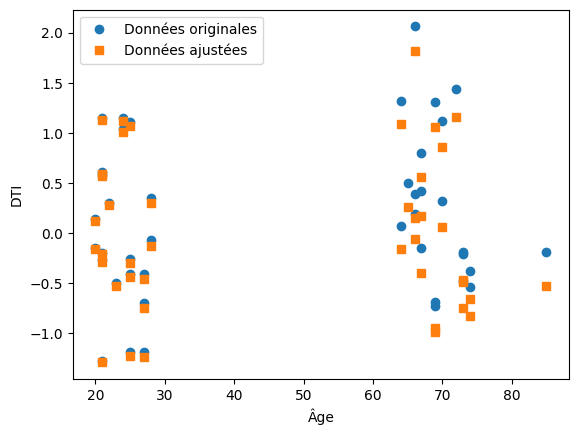

In [162]:
import statsmodels.api as sm

DTI_adjusted = np.zeros_like(DTI_scaled)  # pour stocker les données DTI ajustées

for cc in range(7):
    for seg in range(98):
        data = DTI_scaled[:,seg,cc]  # on prend les données DTI du CC1 pour l'exemple

        data_adjusted = data.copy()

        ### enlever l'effet de l'âge sur le DTI

        # Ajouter une constante à la variable indépendante
        X = sm.add_constant(age)
        y = data

        # Créer le modèle de régression multiple
        model = sm.OLS(y, X)

        # Ajuster le modèle
        results = model.fit()   

        # Calculer les résidus
        residuals = results.resid

        # Mettre à jour les données DTI avec les résidus
        data_adjusted = residuals

        DTI_adjusted[:,seg,cc] = data_adjusted  # stocker les données ajustées  


DTI_scaled_saved=DTI_scaled.copy()  # sauvegarder les données DTI originales
DTI_scaled=DTI_adjusted.copy()  # utiliser les données DTI ajustées

plt.plot(age, DTI_scaled_saved[:,10,0], 'o', label='Données originales')
plt.plot(age, DTI_scaled[:,10,0], 's', label='Données ajustées')
plt.xlabel('Âge')
plt.ylabel('DTI')
plt.legend()
plt.show()

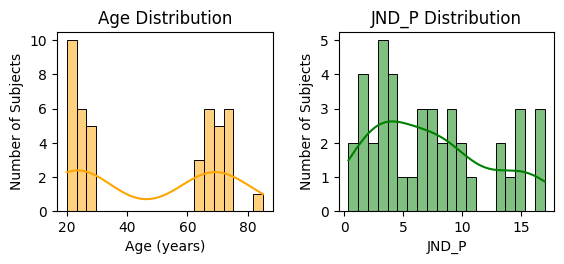

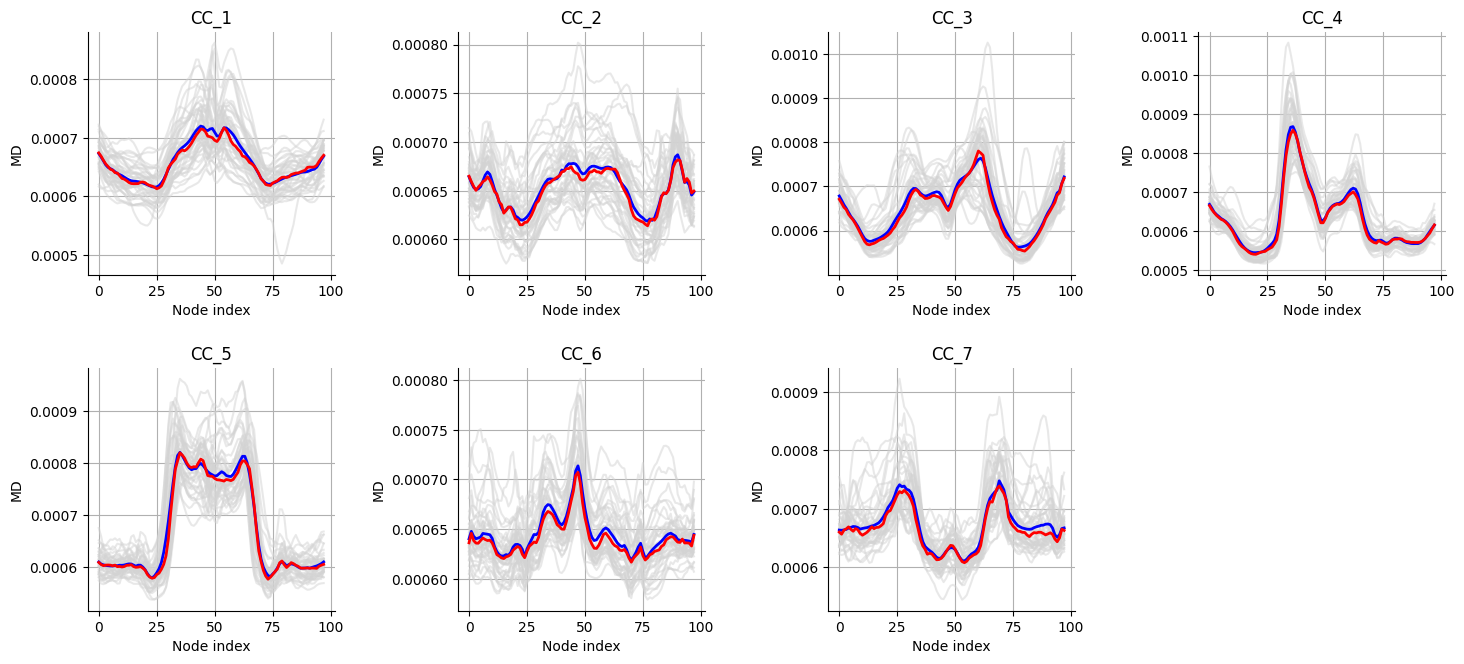

In [163]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs = axs.flatten()

sns.histplot(age, bins=20, ax=axs[0],color='orange',kde=True)
axs[0].set_title('Age Distribution')
axs[0].set_xlabel('Age (years)')
axs[0].set_ylabel('Number of Subjects')
sns.histplot(jnd, bins=20, ax=axs[1],color='green',kde=True)
axs[1].set_title('JND_P Distribution')
axs[1].set_xlabel('JND_P')
axs[1].set_ylabel('Number of Subjects')
plt.tight_layout(pad=2.0)
plt.show()

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[i].plot(DTI[:,:,i].mean(axis=0), color='blue', linewidth=2)
    axs[i].plot(np.median(DTI_all[:,:,i], axis=0), color='red', linewidth=2)
    axs[i].set_xlabel('Node index')
    axs[i].set_ylabel(metricsDTI)
    axs[i].grid(True)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].set_title(CCx)
    
fig.delaxes(axs[7])
plt.tight_layout(pad=2.0)


Feat selectio based on simple lin regression using f_regression

Feat selection based on simple linear regression using f_regression

CC 1 - Best features for JND: [26 27 25 28 36 24 37 29 35 23]
CC 1 - Best features for Age: [63 58 56 42 41 57 50 40 33 60]
CC 2 - Best features for JND: [33 32 34 35 47 46 31 30 36 29]
CC 2 - Best features for Age: [ 7  8 40  3 57 56 33 17 55 83]
CC 3 - Best features for JND: [ 1  0  2  3  4 45  5 46 66 88]
CC 3 - Best features for Age: [93 45 48 38 95 59 34 39 41 43]
CC 4 - Best features for JND: [82 83 84 81 85 50 87 86 61 51]
CC 4 - Best features for Age: [35  1 63  0 34 36 67  2 68 42]
CC 5 - Best features for JND: [ 0  1 88 17 60 62 59 61 87 90]
CC 5 - Best features for Age: [32 33 59 92 34 61 63 15 64 84]
CC 6 - Best features for JND: [68 69 63 95 94 62 64 61 27 66]
CC 6 - Best features for Age: [34 68 66 25 39 97 49 33 32 59]
CC 7 - Best features for JND: [36 35 34 37 71 33 83 82 72 96]
CC 7 - Best features for Age: [67 66 34 35 69 33 28 31 95 50]


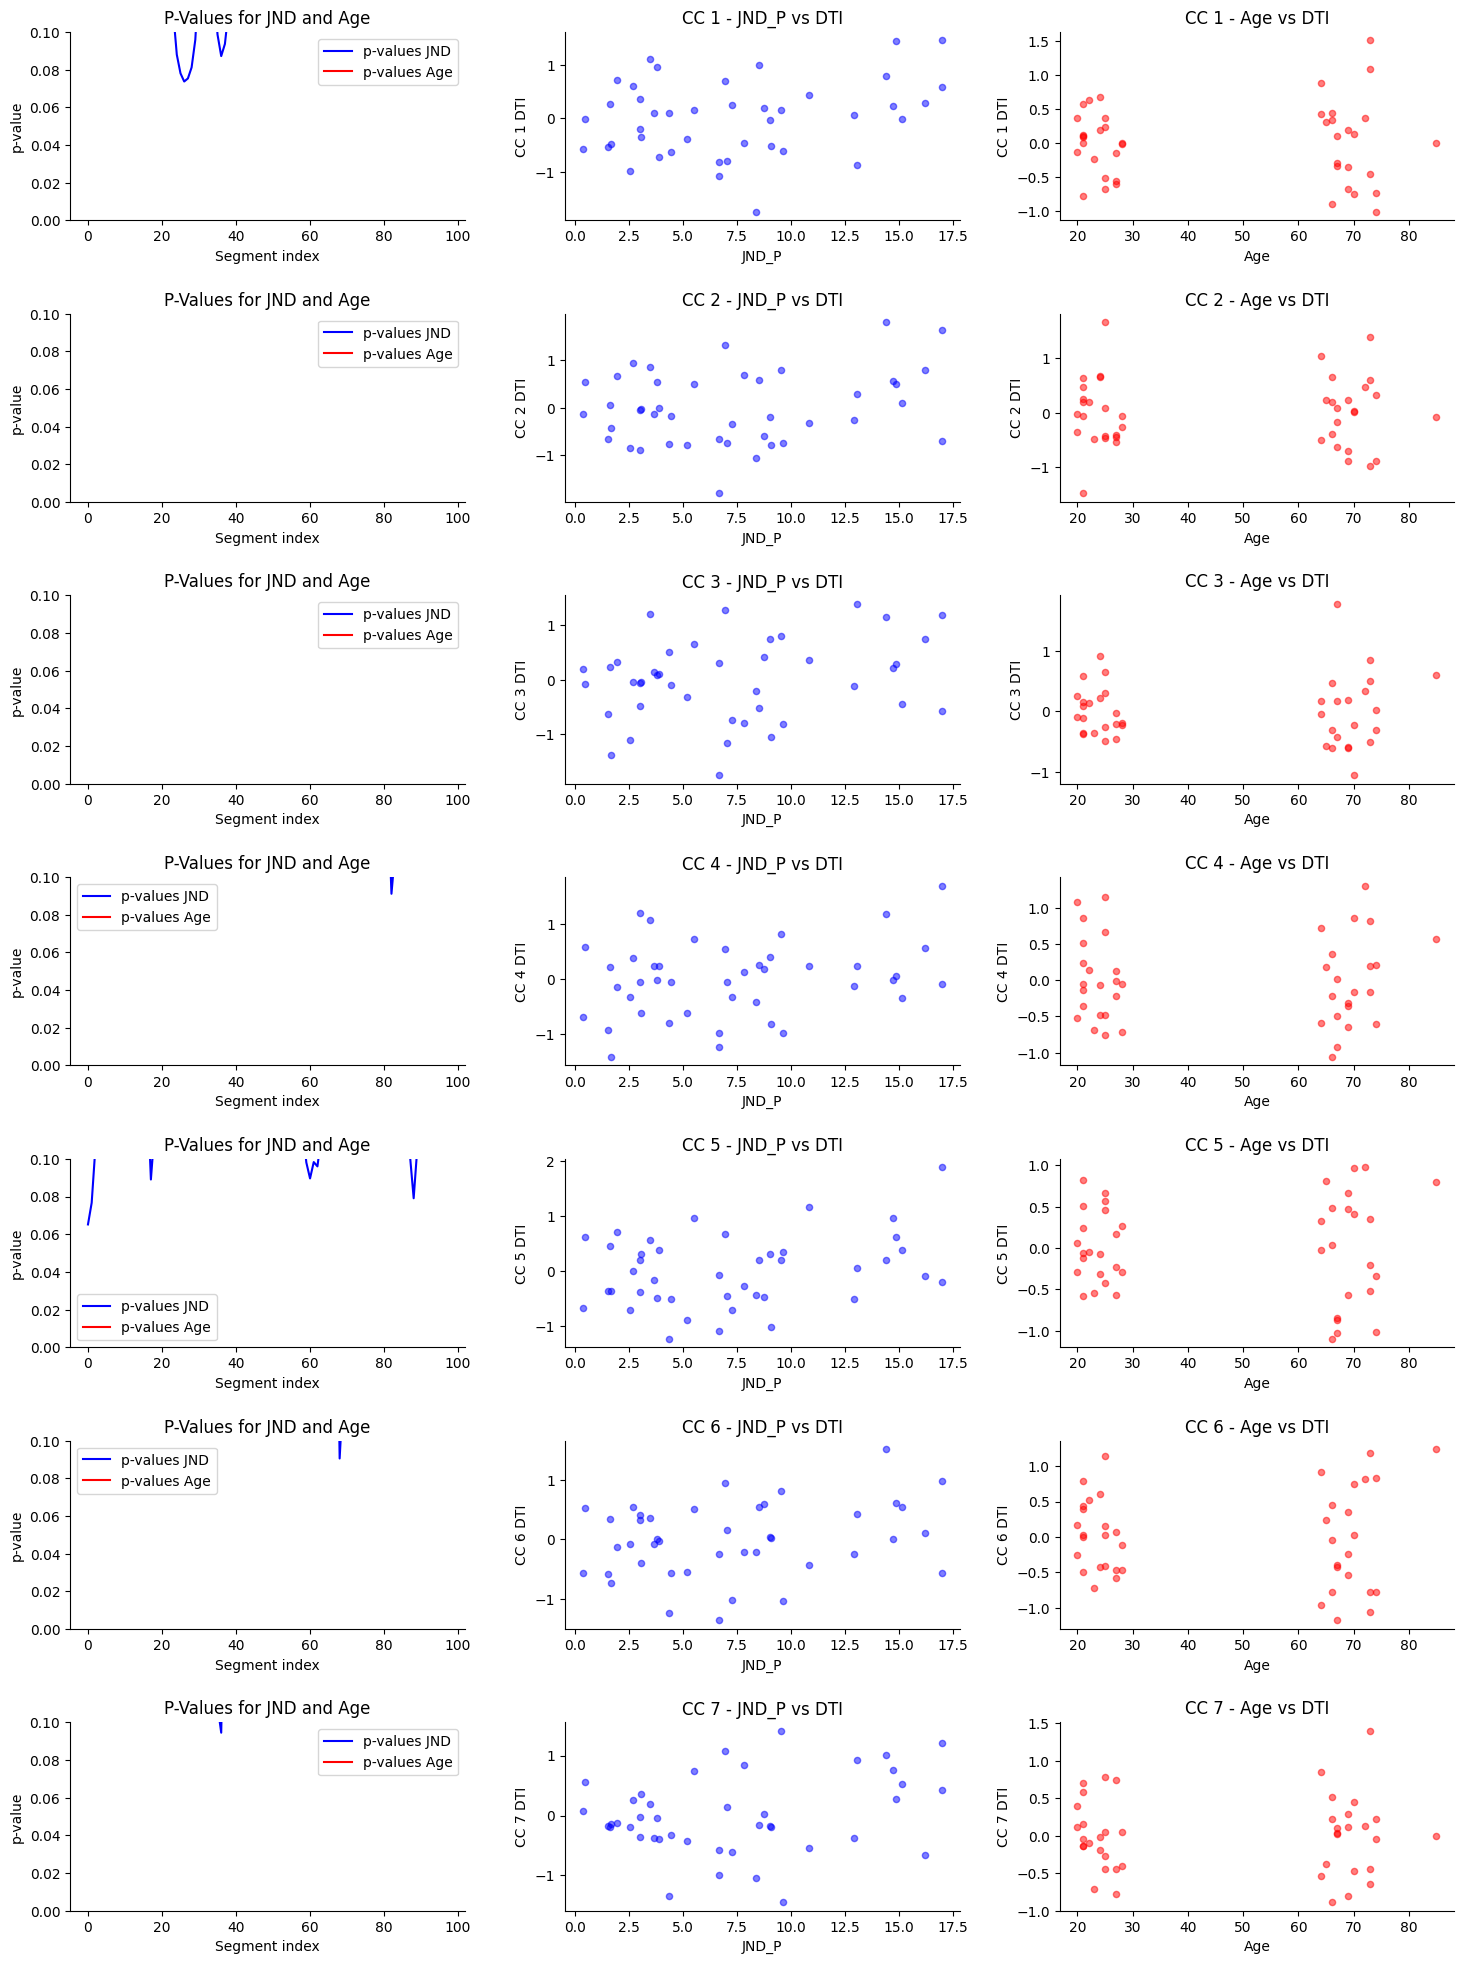

In [164]:
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

f_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
f_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

print('Feat selection based on simple linear regression using f_regression\n')

for cc in range(1,8):
        
    f_statistic_jnd, p_values_jnd = f_regression(DTI_scaled[:,:,cc-1], jnd )
    f_statistic_age, p_values_age = f_regression(DTI_scaled[:,:,cc-1], age )

    f_reg_best_features_jnd_cc = np.argsort(p_values_jnd)[:97]
    f_reg_best_features_age_cc = np.argsort(p_values_age)[:97]
    
    print(f'CC {cc} - Best features for JND: {f_reg_best_features_jnd_cc[:10]}')
    print(f'CC {cc} - Best features for Age: {f_reg_best_features_age_cc[:10]}')

    f_reg_best_features_jnd_cc_allCC[cc-1,:]= f_reg_best_features_jnd_cc[:10]
    f_reg_best_features_age_cc_allCC[cc-1,:] = f_reg_best_features_age_cc[:10]

    axs[cc-1,0].plot(p_values_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(p_values_age, color='red', label='p-values Age')

    axs[cc-1,0].set_ylim(0, 0.1)
    axs[cc-1,0].set_xlabel('Segment index')
    axs[cc-1,0].set_ylabel('p-value')
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('P-Values for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)


    featn_jnd=f_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=f_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')
    
plt.tight_layout(pad=2.0)



based on r_regression

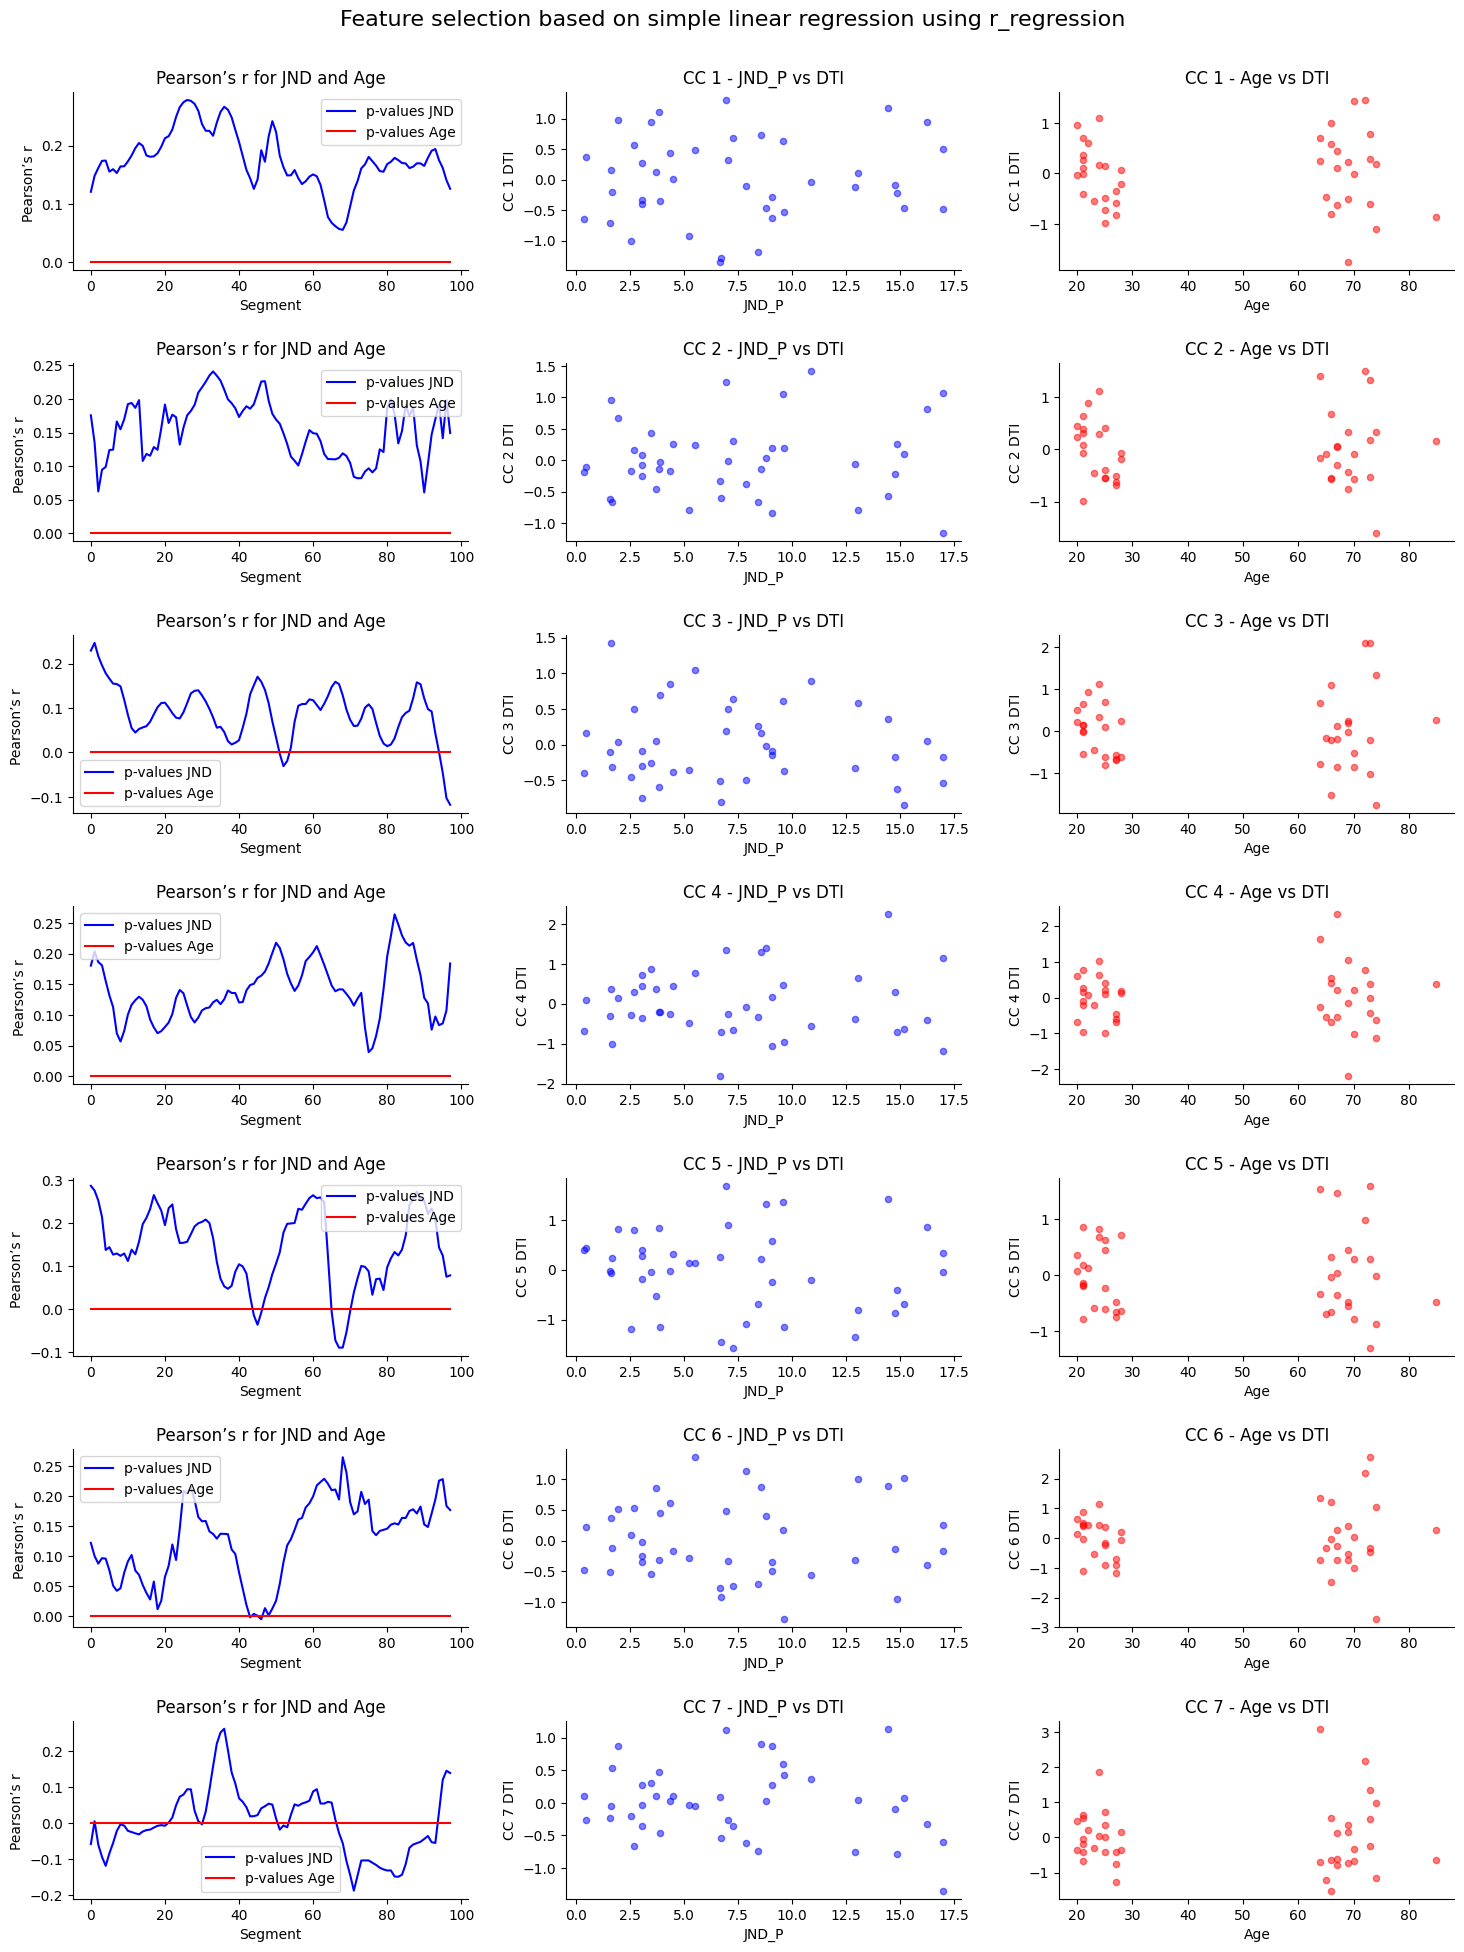

In [165]:
from sklearn.feature_selection import r_regression

####

from sklearn.feature_selection import r_regression

fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(15, 20))

r_reg_best_features_jnd_cc_allCC = np.zeros((7,10), dtype=int)
r_reg_best_features_age_cc_allCC = np.zeros((7,10), dtype=int)

r_reg_age_allcc = np.zeros((7,98))
for cc in range(1,8):   

    r_reg_jnd = r_regression(DTI_scaled[:,:,cc-1], jnd)
    r_reg_age = r_regression(DTI_scaled[:,:,cc-1], age)

    r_reg_age_allcc[cc-1,:] = r_reg_age
    
    r_reg_best_features_jnd_cc = np.argsort(r_reg_jnd)[:97]
    r_reg_best_features_age_cc = np.argsort(r_reg_age)[:97]



  
    
    if metricsDTI=='FA':
        r_reg_best_features_jnd_cc_allCC[cc-1,:]= r_reg_best_features_jnd_cc[:10]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[:10]
    else: 
        r_reg_best_features_jnd_cc_allCC[cc-1,:] = r_reg_best_features_jnd_cc[-10:]
        r_reg_best_features_age_cc_allCC[cc-1,:] = r_reg_best_features_age_cc[-10:]

    axs[cc-1,0].plot(r_reg_jnd, color='blue', label='p-values JND')
    axs[cc-1,0].plot(r_reg_age, color='red', label='p-values Age')

    axs[cc-1,0].set_xlabel('Segment')
    axs[cc-1,0].set_ylabel('Pearson’s r ')  
    axs[cc-1,0].legend()
    axs[cc-1,0].set_title('Pearson’s r for JND and Age')
    axs[cc-1,0].spines['top'].set_visible(False)
    axs[cc-1,0].spines['right'].set_visible(False)

   
    featn_jnd=r_reg_best_features_jnd_cc[0]  # on prend la feature la plus significative pour JND
    featn_age=r_reg_best_features_age_cc[0]  # on prend la feature la plus significative pour Age

    axs[cc-1,1].scatter(jnd, DTI_scaled[:,featn_jnd,cc-1], color='blue', label='Données', alpha=0.5, s=20)
    axs[cc-1,2].scatter(age, DTI_scaled[:,featn_age,cc-1], color='red', label='Données', alpha=0.5, s=20)
    axs[cc-1,1].set_xlabel('JND_P')
    axs[cc-1,1].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,2].set_xlabel('Age')
    axs[cc-1,2].set_ylabel(f'CC {cc} DTI')
    axs[cc-1,1].spines['top'].set_visible(False)
    axs[cc-1,2].spines['top'].set_visible(False)
    axs[cc-1,1].spines['right'].set_visible(False)
    axs[cc-1,2].spines['right'].set_visible(False)
    axs[cc-1,1].set_title(f'CC {cc} - JND_P vs DTI')
    axs[cc-1,2].set_title(f'CC {cc} - Age vs DTI')

fig.suptitle('Feature selection based on simple linear regression using r_regression\n', fontsize=16)
    
plt.tight_layout(pad=2.0) 

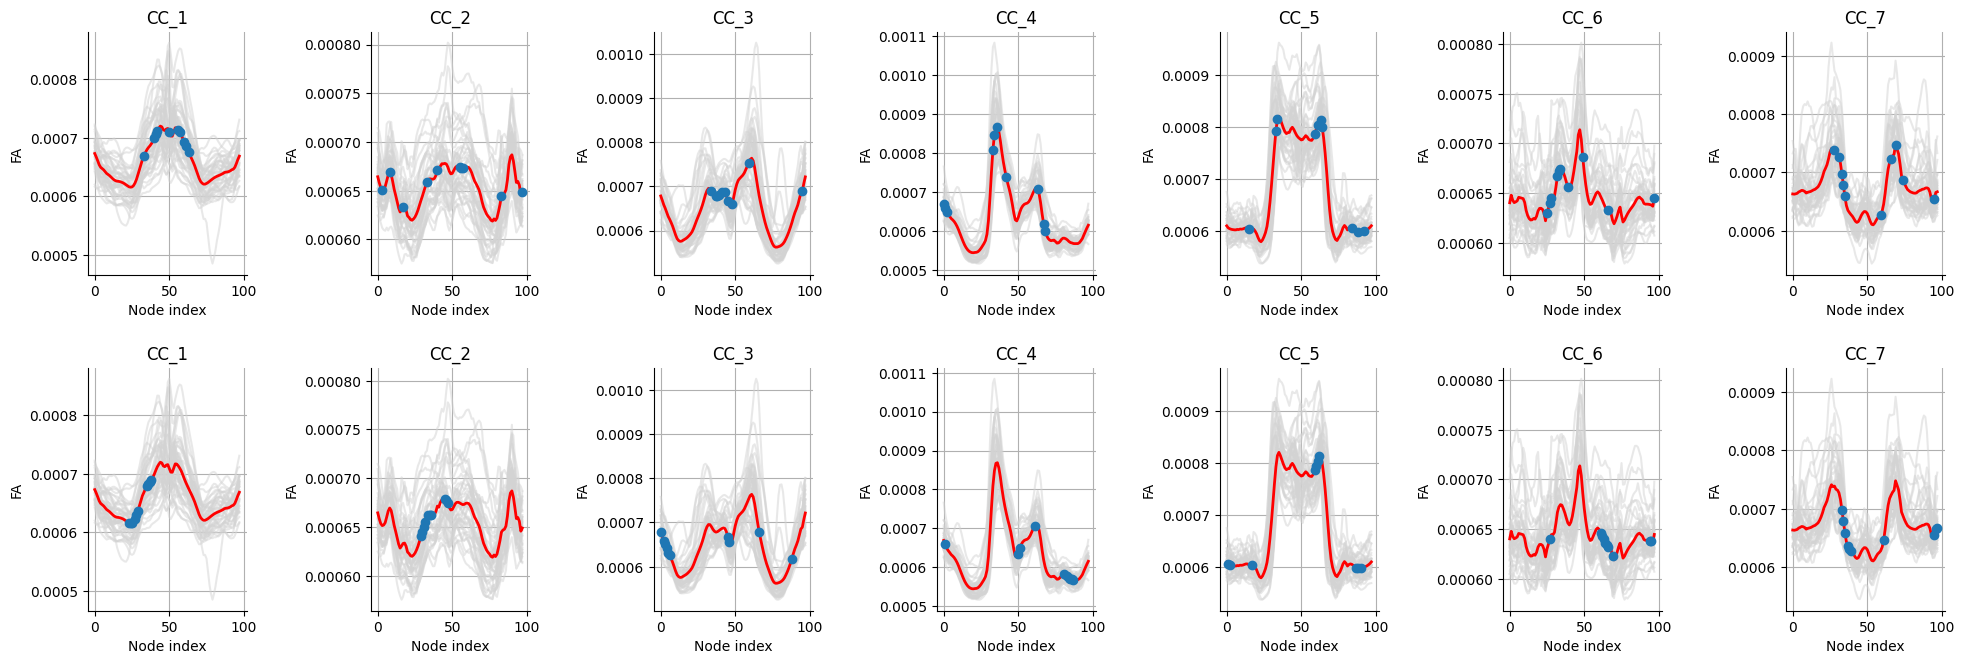

In [166]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(r_reg_best_features_age_cc_allCC[i,:], DTI[:,r_reg_best_features_age_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
   

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

plt.tight_layout(pad=2.0)



In [167]:
r_reg_best_features_jnd_cc_allCC

array([[38, 23, 35, 29, 37, 24, 36, 28, 25, 27],
       [45, 29, 36, 30, 31, 46, 47, 35, 34, 32],
       [ 6, 88, 66, 46,  5, 45,  4,  3,  2,  0],
       [ 1, 51, 61, 86, 87, 50, 85, 81, 84, 83],
       [ 2, 90, 87, 61, 59, 62, 60, 17, 88,  1],
       [65, 66, 27, 61, 64, 62, 94, 95, 63, 69],
       [61, 39, 95, 97, 38, 96, 33, 37, 34, 35]])

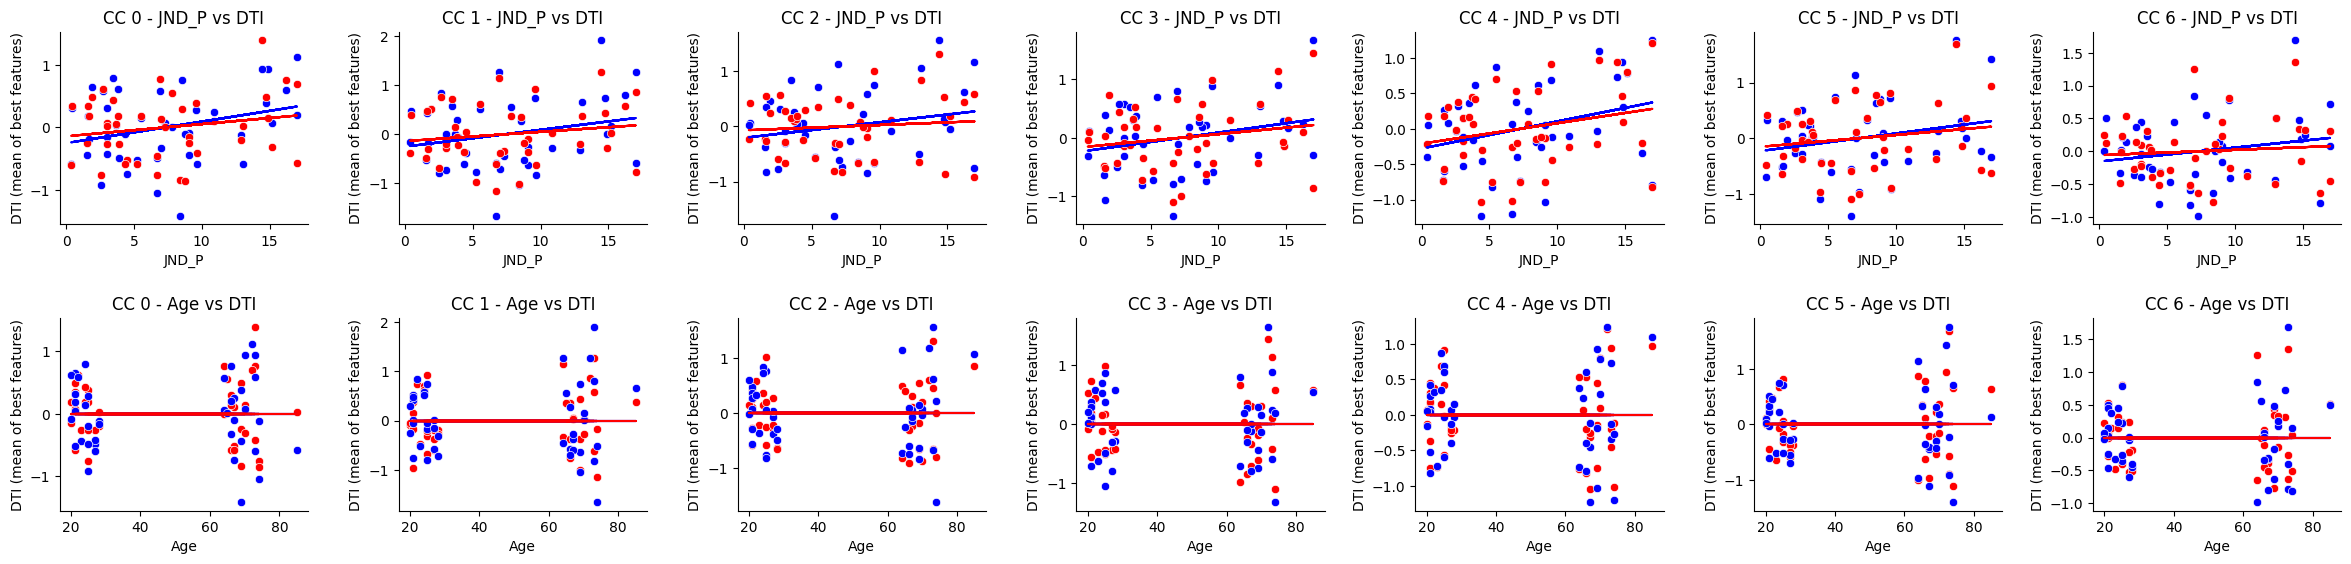

In [168]:
import statsmodels.api as sm
 

fig,axs = plt.subplots(nrows=2, ncols=7, figsize=(24,6))

for cc in range(7):

    x = sm.add_constant(jnd)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2


    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='blue')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=jnd, ax=axs[0,cc], color='red') 
    axs[0,cc].set_title(f'CC {cc} - JND_P vs DTI')
    axs[0,cc].spines['top'].set_visible(False)
    axs[0,cc].spines['right'].set_visible(False)
    axs[0,cc].set_xlabel('JND_P')
    axs[0,cc].set_ylabel('DTI (mean of best features)')
    # Tracer la ligne de régression
    axs[0,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[0,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')



    
    x = sm.add_constant(age)
    y1=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    y2=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1)
    # Créer le modèle de régression linéaire
    model1 = sm.OLS(y1, x)
    model2= sm.OLS(y2, x)
    results1 = model1.fit()
    results2 = model2.fit()
    slope1 = results1.params[1]
    intercept1 = results1.params[0]
    slope2 = results2.params[1]
    intercept2 = results2.params[0]

    # Créer une ligne de régression
    regression_line1 = slope1 * x[:, 1] + intercept1
    regression_line2 = slope2 * x[:, 1] + intercept2
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='red')
    sns.scatterplot(y=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc].mean(axis=1), x=age, ax=axs[1,cc], color='blue')
    axs[1,cc].set_title(f'CC {cc} - Age vs DTI')
    axs[1,cc].spines['top'].set_visible(False)
    axs[1,cc].spines['right'].set_visible(False)
    axs[1,cc].set_xlabel('Age')
    axs[1,cc].set_ylabel('DTI (mean of best features)')
    axs[1,cc].plot(x[:, 1], regression_line1, color='blue', label='Régression linéaire')
    axs[1,cc].plot(x[:, 1], regression_line2, color='red', label='Régression linéaire')

plt.tight_layout(pad=2.0)



       


Regression prediction test on cc 7 best feat

[74 59 31 95 28 33 69 35 34 66]
[61 39 95 97 38 96 33 37 34 35]
Mean MSE for JND: 35.1948 ± 13.6459
Mean MSE for Age: 1145.3961 ± 201.4396
P-value from independent t-test: 0.0000
Mean R² for JND: -0.7437 ± 0.8541
Mean R² for Age: -1.4093 ± 0.6931
P-value from independent t-test: 0.0000
Mean MAE for JND: 4.9143 ± 0.9582
Mean MAE for Age: 29.0519 ±   3.1998
P-value from independent t-test: 0.0000


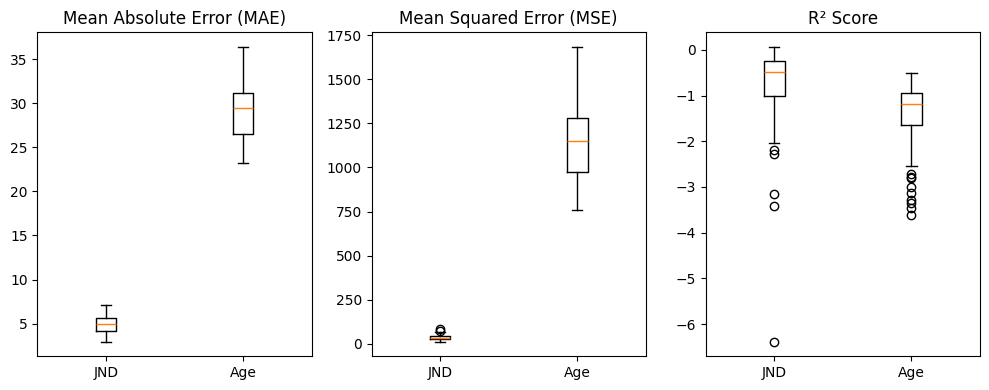

In [169]:
cc=6
print(r_reg_best_features_age_cc_allCC[cc])
print(r_reg_best_features_jnd_cc_allCC[cc])

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel as t_test_rel, ttest_ind as t_test_ind

mae_jnd_rd = []
mae_age_rd = []
mse_jnd_rd = []
mse_age_rd = []
r2_jnd_rd = []
r2_age_rd = []

for rd in range(100):

    X_train,X_test,y_train,y_test=train_test_split(DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc], jnd, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)

    mae_jnd_rd.append(mean_absolute_error(y_test, y_pred))
    mse_jnd_rd.append(mean_squared_error(y_test, y_pred))
    r2_jnd_rd.append(r2_score(y_test, y_pred))

    X_train,X_test,y_train,y_test=train_test_split(DTI_scaled[:,r_reg_best_features_age_cc_allCC[cc,:].tolist(),cc], age, test_size=0.2, random_state=rd)
    regr=svm.SVR(kernel='linear')
    regr.fit(X_train, y_train)
    y_pred = regr.predict(X_test)
    regr.score(X_test, y_test)
  
    mae_age_rd.append(mean_absolute_error(y_test, y_pred))
    mse_age_rd.append(mean_squared_error(y_test, y_pred))
    r2_age_rd.append(r2_score(y_test, y_pred))




fig,ax=plt.subplots(nrows=1, ncols=3,figsize=(10,4))
ax[0].boxplot([mae_jnd_rd, mae_age_rd], labels=['JND', 'Age'])
ax[0].set_title('Mean Absolute Error (MAE)')
ax[1].boxplot([mse_jnd_rd, mse_age_rd], labels=['JND', 'Age'])
ax[1].set_title('Mean Squared Error (MSE)')
ax[2].boxplot([r2_jnd_rd, r2_age_rd], labels=['JND', 'Age'])
ax[2].set_title('R² Score')
plt.tight_layout()

t,pvalue=t_test_ind(mse_jnd_rd, mse_age_rd)
print(f'Mean MSE for JND: {np.mean(mse_jnd_rd):.4f} ± {np.std(mse_jnd_rd):.4f}')
print(f'Mean MSE for Age: {np.mean(mse_age_rd):.4f} ± {np.std(mse_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(r2_jnd_rd, r2_age_rd)
print(f'Mean R² for JND: {np.mean(r2_jnd_rd):.4f} ± {np.std(r2_jnd_rd):.4f}')
print(f'Mean R² for Age: {np.mean(r2_age_rd):.4f} ± {np.std(r2_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

t,pvalue=t_test_ind(mae_jnd_rd, mae_age_rd)
print(f'Mean MAE for JND: {np.mean(mae_jnd_rd):.4f} ± {np.std(mae_jnd_rd):.4f}')
print(f'Mean MAE for Age: {np.mean(mae_age_rd):.4f} ±   {np.std(mae_age_rd):.4f}')
print(f'P-value from independent t-test: {pvalue:.4f}')

In [170]:


DTI_JND=pd.DataFrame([])
DTI_AGE=pd.DataFrame([])
for cc in range(1,8):
    DTI_JND_tmp=pd.DataFrame(DTI_scaled[:,f_reg_best_features_jnd_cc_allCC[cc-1],cc-1])
    DTI_JND_tmp.columns = [f'CC{cc}_{idx}' for idx in f_reg_best_features_jnd_cc_allCC[cc-1]]
    DTI_JND=pd.concat([DTI_JND, DTI_JND_tmp], axis=1)

    DTI_AGE_tmp=pd.DataFrame(DTI_scaled[:,f_reg_best_features_age_cc_allCC[cc-1],cc-1])
    DTI_AGE_tmp.columns = [f'CC{cc}_{idx}' for idx in f_reg_best_features_age_cc_allCC[cc-1]]
    DTI_AGE=pd.concat([DTI_AGE, DTI_AGE_tmp], axis=1)




DTI_JND.describe()


,CC1_26,CC1_27,CC1_25,CC1_28,CC1_36,CC1_24,CC1_37,CC1_29,CC1_35,CC1_23,...,CC7_36,CC7_35,CC7_34,CC7_37,CC7_71,CC7_33,CC7_83,CC7_82,CC7_72,CC7_96
count,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,...,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01
mean,-4.427675e-17,-3.832913e-17,-1.004487e-16,-1.321694e-16,-2.167578e-16,-3.700743e-17,-3.119198e-16,-8.723181e-17,-2.788775e-16,-4.097252e-17,...,-2.141144e-16,-1.044138e-16,-3.700743e-17,-2.088277e-16,-3.145632e-16,2.544261e-17,3.965082e-18,-7.401487e-17,-3.502489e-16,-1.453863e-16
std,7.069278e-01,6.947915e-01,6.371881e-01,7.804656e-01,5.265413e-01,6.781468e-01,5.436869e-01,7.034129e-01,5.612086e-01,7.446563e-01,...,6.607415e-01,5.541075e-01,5.168642e-01,6.282578e-01,5.443294e-01,5.281927e-01,8.853579e-01,8.893984e-01,6.619424e-01,8.606872e-01
min,-1.747830e+00,-1.679460e+00,-1.528001e+00,-1.789151e+00,-1.102664e+00,-1.556607e+00,-1.231457e+00,-1.490079e+00,-1.135457e+00,-1.777442e+00,...,-1.445390e+00,-1.090358e+00,-1.029701e+00,-1.510758e+00,-1.345757e+00,-1.004260e+00,-1.110173e+00,-1.128172e+00,-1.477353e+00,-1.455919e+00
25%,-5.363891e-01,-5.738907e-01,-4.309388e-01,-6.246744e-01,-3.723963e-01,-4.872802e-01,-3.418331e-01,-4.722205e-01,-3.637834e-01,-4.709654e-01,...,-3.739796e-01,-2.863344e-01,-3.368813e-01,-3.864516e-01,-3.435899e-01,-3.112738e-01,-6.758018e-01,-6.686269e-01,-4.329874e-01,-5.438823e-01
50%,8.182878e-02,7.527990e-02,7.498278e-02,1.479324e-01,2.483072e-02,1.350623e-01,6.761662e-02,2.575365e-02,-1.002028e-02,1.390773e-01,...,-1.339191e-01,-9.445880e-02,-2.094443e-02,-4.777002e-02,1.020385e-04,-8.676801e-02,-2.408488e-01,-2.199525e-01,-1.049297e-01,-9.729044e-02
75%,4.164660e-01,3.502459e-01,3.642900e-01,3.767840e-01,3.784861e-01,3.365320e-01,3.034200e-01,3.858000e-01,4.375181e-01,3.591043e-01,...,4.072258e-01,2.634192e-01,3.210369e-01,4.169279e-01,2.964501e-01,3.300623e-01,2.948067e-01,3.450459e-01,5.293200e-01,4.108871e-01
max,1.450879e+00,1.408143e+00,1.357419e+00,1.550473e+00,1.260095e+00,1.531110e+00,1.280278e+00,1.471924e+00,1.283831e+00,1.731981e+00,...,1.410794e+00,1.200154e+00,1.103670e+00,1.175280e+00,1.136063e+00,1.287127e+00,2.489241e+00,2.445818e+00,1.598826e+00,2.644051e+00


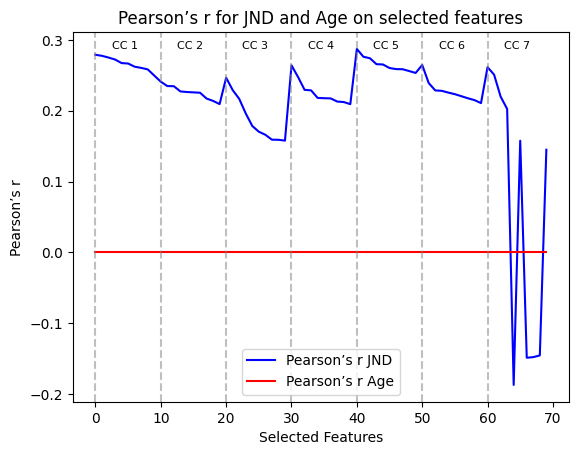

In [171]:
cc=1
r_reg_jnd70 = r_regression(DTI_JND, jnd)
r_reg_age70 = r_regression(DTI_AGE, age)


plt.plot(r_reg_jnd70, color='blue', label='Pearson’s r JND')
plt.plot(r_reg_age70, color='red', label='Pearson’s r Age')
plt.xlabel('Selected Features')
plt.ylabel('Pearson’s r')
plt.title('Pearson’s r for JND and Age on selected features')
plt.legend()

for i in range(7):
    plt.axvline(x=i*10, color='gray', linestyle='--', alpha=0.5)
    plt.text(i*10 + 2.5, max(max(r_reg_jnd70), max(r_reg_age70)), f'CC {i+1}', color='black', fontsize=8)


<Axes: >

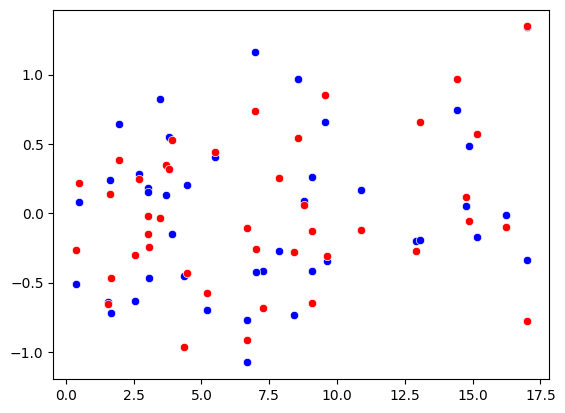

In [172]:
from sklearn.feature_selection import SequentialFeatureSelector

X=DTI_JND
y=jnd
sfs = SequentialFeatureSelector(estimator=svm.SVR(kernel='linear'), n_features_to_select=10, direction='forward')
sfs.fit(X, y)
X10=sfs.transform(X)

sns.scatterplot(x=y, y=X10.mean(axis=1), color='blue')


X=DTI_AGE
y=jnd
sfs = SequentialFeatureSelector(estimator=svm.SVR(kernel='linear'), n_features_to_select=10, direction='forward')
sfs.fit(X, y)
X10=sfs.transform(X)

sns.scatterplot(x=y, y=X10.mean(axis=1), color='red')


In [173]:
Aging_INDICES['JND_group3'] = pd.qcut(Aging_INDICES['JND_P'], q=3, labels=[0,1,2])
Aging_INDICES['JND_group3']

0     2
1     1
2     2
3     0
4     0
5     1
6     2
7     1
8     0
9     0
10    0
11    0
12    2
13    2
14    2
15    1
16    0
17    0
18    2
19    1
20    0
21    2
22    1
23    0
24    0
25    2
26    0
27    2
28    1
29    0
30    1
31    1
32    0
33    1
34    1
35    1
36    2
37    1
38    2
39    2
40    2
41    1
Name: JND_group3, dtype: category
Categories (3, int64): [0 < 1 < 2]

JND_group
0    21
1    21
Name: count, dtype: int64
T-test JND group: t=-1.5866, p=0.1205
T-test JND group: t=-1.3551, p=0.1830
T-test Age group: t=0.0196, p=0.9845
T-test Age group: t=0.0661, p=0.9476


(42, 70)

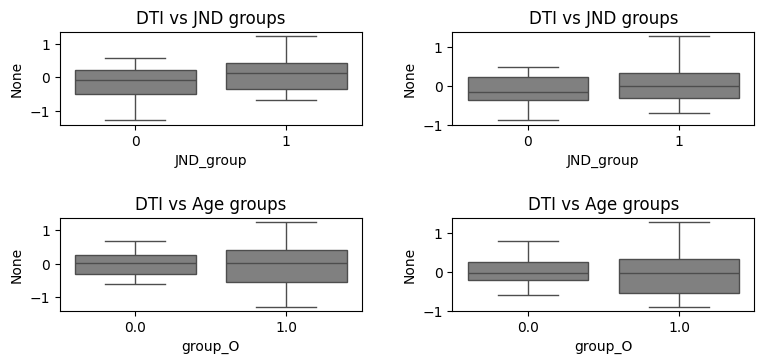

In [174]:


fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(8,4))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,0])
axs[0,0].set_title('DTI vs JND groups')

sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group'], color='grey', ax=axs[0,1])
axs[0,1].set_title('DTI vs JND groups')
print(Aging_INDICES['JND_group'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
axs[1,0].set_title('DTI vs Age groups')
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
axs[1,1].set_title('DTI vs Age groups')
plt.tight_layout(pad=2.0)

t,pval=t_test_ind(DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_JND.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['JND_group']==1])
print(f'T-test JND group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_JND.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
t,pval=t_test_ind(DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==0], DTI_AGE.mean(axis=1)[Aging_INDICES['group_O']==1])
print(f'T-test Age group: t={t:.4f}, p={pval:.4f}')
DTI_JND.shape

JND_group3
0    14
1    14
2    14
Name: count, dtype: int64


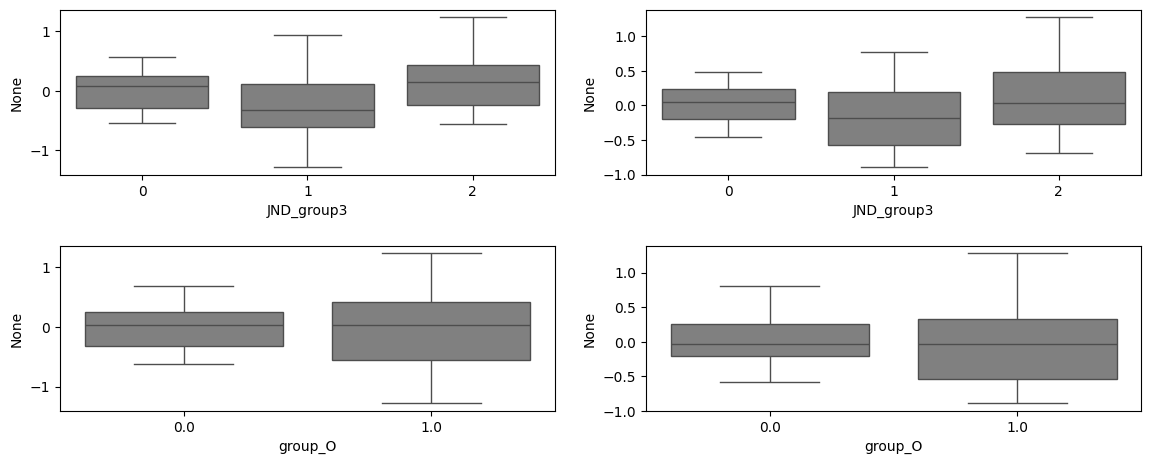

In [175]:


fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['JND_group3'], color='grey', ax=axs[0,1])
print(Aging_INDICES['JND_group3'].value_counts())
sns.boxplot(y=DTI_JND.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,0])
sns.boxplot(y=DTI_AGE.mean(axis=1), x=Aging_INDICES['group_O'], color='grey', ax=axs[1,1])
plt.tight_layout(pad=2.0)



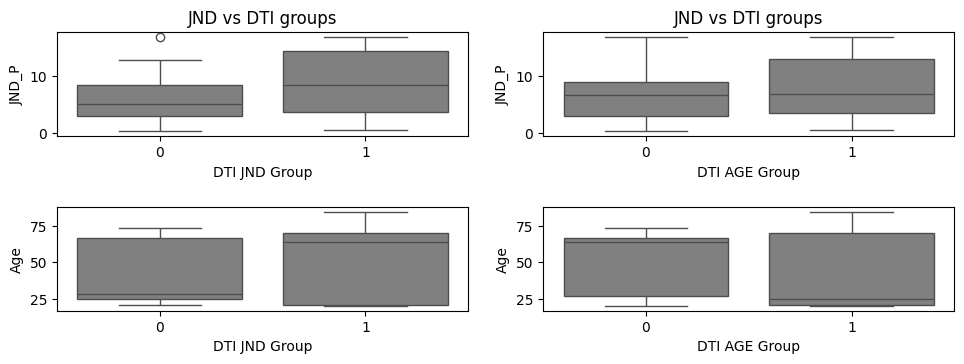

In [176]:
DTI_3g_JND = pd.qcut(DTI_JND.mean(axis=1), q=2, labels=[0,1])
DTI_3g_AGE = pd.qcut(DTI_AGE.mean(axis=1), q=2, labels=[0,1])

fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(10,4))

sns.boxplot(y=jnd,x=DTI_3g_JND,color='grey', ax=axs[0,0])
sns.boxplot(y=jnd,x=DTI_3g_AGE,color='grey', ax=axs[0,1])
axs[0,0].set_xlabel('DTI JND Group')
axs[0,0].set_ylabel('JND_P')
axs[0,1].set_xlabel('DTI AGE Group')
axs[0,1].set_ylabel('JND_P')

sns.boxplot(y=age,x=DTI_3g_JND,color='grey', ax=axs[1,0])
sns.boxplot(y=age,x=DTI_3g_AGE,color='grey', ax=axs[1,1])
axs[1,0].set_xlabel('DTI JND Group')
axs[1,0].set_ylabel('Age')
axs[1,1].set_xlabel('DTI AGE Group')
axs[1,1].set_ylabel('Age')

axs[0,0].set_title('JND vs DTI groups')
axs[0,1].set_title('JND vs DTI groups')
plt.tight_layout(pad=2.0)



Text(0.5, 1.0, 'JND vs DTI groups')

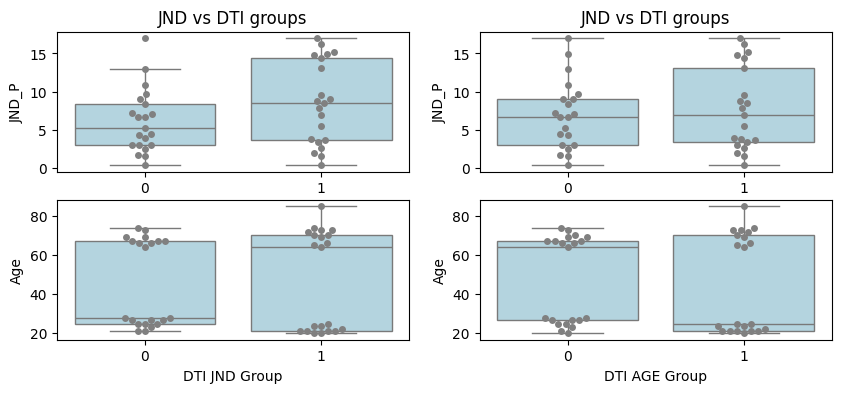

In [177]:
fig,axs = plt.subplots(nrows=2, ncols=2, figsize=(10,4))

sns.swarmplot(y=jnd,x=DTI_3g_JND,color='grey', ax=axs[0,0])
sns.boxplot(y=jnd,x=DTI_3g_JND,color='lightblue', ax=axs[0,0], showfliers=False)

sns.swarmplot(y=jnd,x=DTI_3g_AGE,color='grey', ax=axs[0,1])
sns.boxplot(y=jnd,x=DTI_3g_AGE,color='lightblue', ax=axs[0,1], showfliers=False)
axs[0,0].set_xlabel('DTI JND Group')
axs[0,0].set_ylabel('JND_P')
axs[0,1].set_xlabel('DTI AGE Group')
axs[0,1].set_ylabel('JND_P')
sns.swarmplot(y=age,x=DTI_3g_JND,color='grey', ax=axs[1,0])
sns.boxplot(y=age,x=DTI_3g_JND,color='lightblue', ax=axs[1,0], showfliers=False)
sns.swarmplot(y=age,x=DTI_3g_AGE,color='grey', ax=axs[1,1])
sns.boxplot(y=age,x=DTI_3g_AGE,color='lightblue', ax=axs[1,1], showfliers=False)
axs[1,0].set_xlabel('DTI JND Group')
axs[1,0].set_ylabel('Age')
axs[1,1].set_xlabel('DTI AGE Group')
axs[1,1].set_ylabel('Age')
axs[0,0].set_title('JND vs DTI groups')
axs[0,1].set_title('JND vs DTI groups')


CC 1 - ROC Curve Analysis

Mean AUC for Age: 0.3812 ± 0.0757
Mean AUC for JND: 0.4984 ± 0.1187
P-value from independent t-test: 0.0000
CC 2 - ROC Curve Analysis

Mean AUC for Age: 0.3835 ± 0.0764
Mean AUC for JND: 0.4829 ± 0.0945
P-value from independent t-test: 0.0000
CC 3 - ROC Curve Analysis

Mean AUC for Age: 0.3309 ± 0.0771
Mean AUC for JND: 0.4155 ± 0.0960
P-value from independent t-test: 0.0000
CC 4 - ROC Curve Analysis

Mean AUC for Age: 0.3404 ± 0.0690
Mean AUC for JND: 0.4917 ± 0.0995
P-value from independent t-test: 0.0000
CC 5 - ROC Curve Analysis

Mean AUC for Age: 0.3445 ± 0.0762
Mean AUC for JND: 0.5200 ± 0.1003
P-value from independent t-test: 0.0000
CC 6 - ROC Curve Analysis

Mean AUC for Age: 0.3533 ± 0.0691
Mean AUC for JND: 0.5188 ± 0.1048
P-value from independent t-test: 0.0000
CC 7 - ROC Curve Analysis

Mean AUC for Age: 0.3302 ± 0.0691
Mean AUC for JND: 0.4735 ± 0.0942
P-value from independent t-test: 0.0000


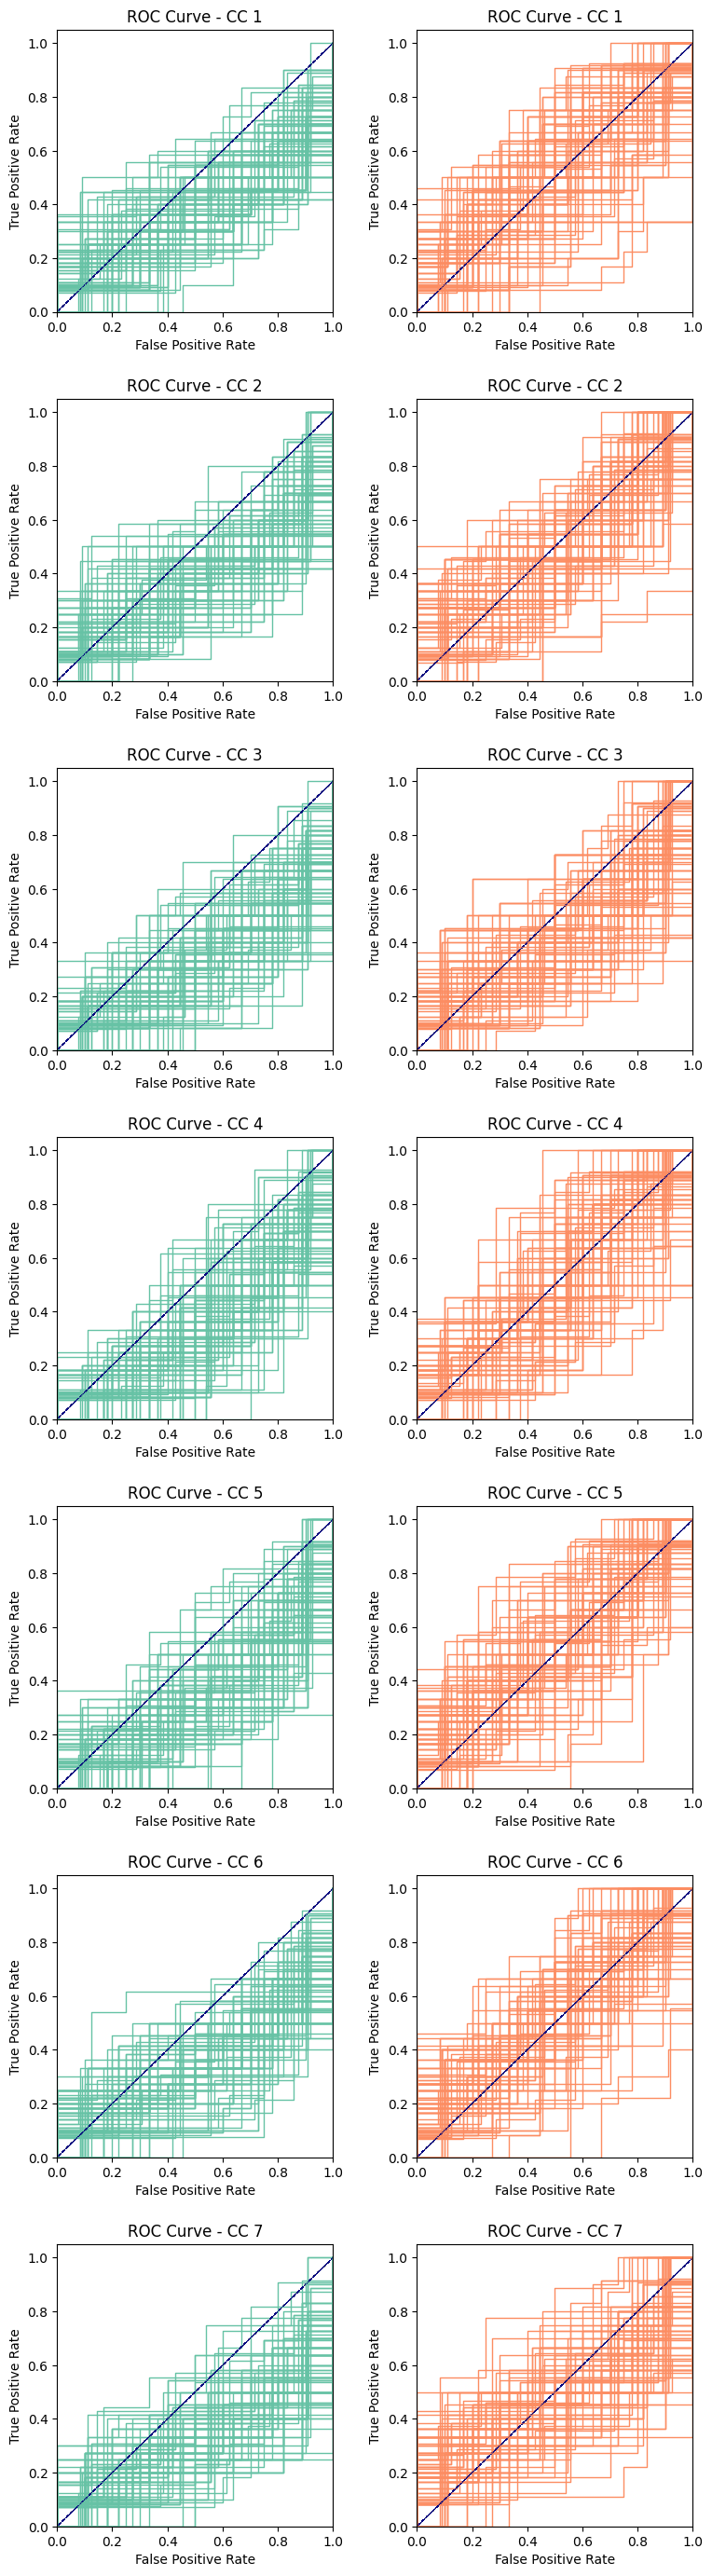

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score





colors = sns.color_palette('Set2')
first_color = colors[0]
second_color = colors[1]


roc_auc_all_cc=[[] for _ in range(7)]

fig, axs = plt.subplots(nrows=7, ncols=2, figsize=(8, 28))
for cc in range(7):
    print(f'CC {cc+1} - ROC Curve Analysis\n')
    
    X=DTI_scaled[:,r_reg_best_features_jnd_cc_allCC[cc,:].tolist(),cc]

    target_var=  ['Age', 'JND']
    roc_auc_all = [[] for _ in target_var]


    for i, target in enumerate(target_var):
        if target == 'Age':
            y=age_grouped

        elif target == 'JND':
            y=jnd_grouped

        for seed in range(100):
            # Diviser les données en ensembles d'entraînement et de test
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)

            # Entraîner un modèle de régression logistique
            model = LogisticRegression()
            model.fit(X_train, y_train)

            # Prédire les probabilités
            y_scores = model.predict_proba(X_test)[:, 1]

            # Calculer les taux de vrais positifs et de faux positifs
            fpr, tpr, thresholds = roc_curve(y_test, y_scores)

            # Calculer l'aire sous la courbe ROC (AUC)
            roc_auc = auc(fpr, tpr)

            # Tracer la courbe ROC
            axs[cc,i].plot(fpr, tpr, color=colors[i], lw=1)
            axs[cc,i].plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle=':')
            axs[cc,i].set_xlim([0.0, 1.0])
            axs[cc,i].set_ylim([0.0, 1.05])
            axs[cc,i].set_xlabel('False Positive Rate')
            axs[cc,i].set_ylabel('True Positive Rate')
            axs[cc,i].set_title( 'ROC Curve - CC {}'.format(cc+1))
            # axs[cc].legend(loc="lower right")

            # Calculer l'AUC
            roc_auc = roc_auc_score(y_test, y_scores)
            roc_auc_all[i].append(roc_auc)
            # print(f'AUC: {roc_auc:.2f}')

    roc_auc_all_cc[cc] = roc_auc_all


    t,pvalue=t_test_ind(roc_auc_all[0], roc_auc_all[1])
    print(f'Mean AUC for Age: {np.mean(roc_auc_all[0]):.4f} ± {np.std(roc_auc_all[0]):.4f}')
    print(f'Mean AUC for JND: {np.mean(roc_auc_all[1]):.4f} ± {np.std(roc_auc_all[1]):.4f}')
    print(f'P-value from independent t-test: {pvalue:.4f}')


plt.tight_layout(pad=2.0)

CC 1 - Mean AUC for Age: 0.3812 ± 0.0757
CC 2 - Mean AUC for Age: 0.3835 ± 0.0764
CC 3 - Mean AUC for Age: 0.3309 ± 0.0771
CC 4 - Mean AUC for Age: 0.3404 ± 0.0690
CC 5 - Mean AUC for Age: 0.3445 ± 0.0762
CC 6 - Mean AUC for Age: 0.3533 ± 0.0691
CC 7 - Mean AUC for Age: 0.3302 ± 0.0691


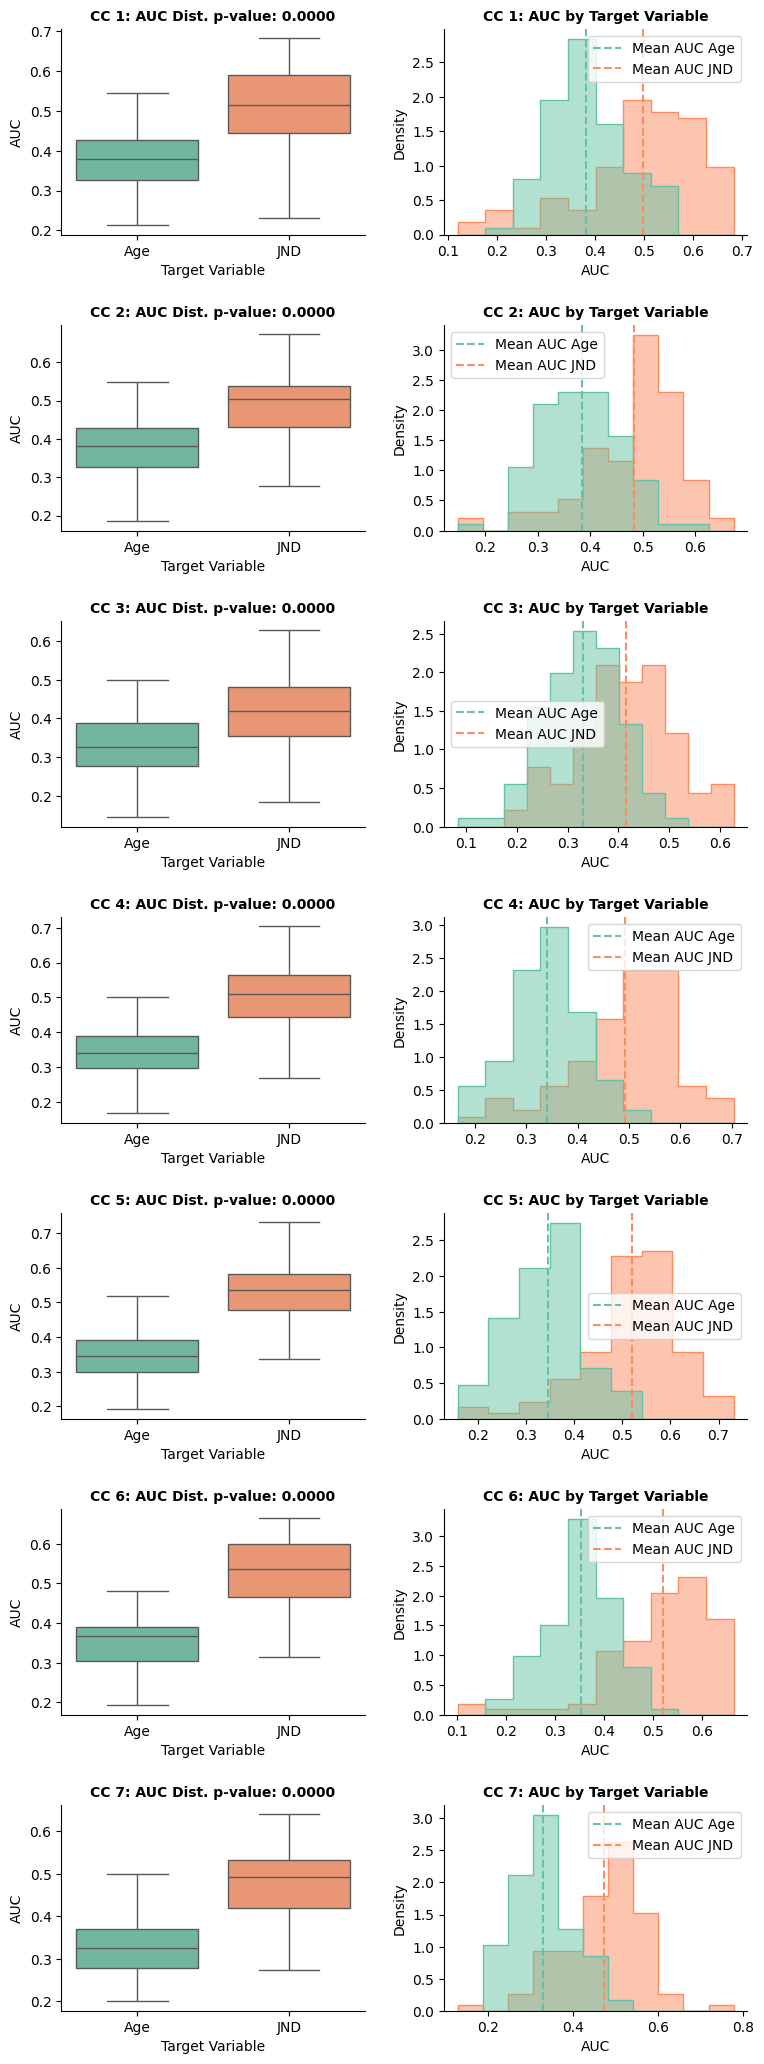

In [179]:


fig,axs = plt.subplots(nrows=7, ncols=2, figsize=(8,21))
for cc in range(7):
    df=pd.DataFrame({'AUC': roc_auc_all_cc[cc][0] + roc_auc_all_cc[cc][1], 'Target': ['Age']*len(roc_auc_all_cc[cc][0]) + ['JND']*len(roc_auc_all_cc[cc][1])})

    sns.boxplot(x='Target', y='AUC', data=df, ax=axs[cc,0], palette='Set2',showfliers=False)
    axs[cc,0].set_title(f'CC {cc+1}: AUC Dist. p-value: {pvalue:.4f}', fontsize=10,fontweight='bold')
    axs[cc,0].set_xlabel('Target Variable')
    axs[cc,0].set_ylabel('AUC')
    axs[cc,0].spines['top'].set_visible(False)
    axs[cc,0].spines['right'].set_visible(False)   
    t,pvalue=t_test_ind(roc_auc_all_cc[cc][0], roc_auc_all_cc[cc][1])
    print(f'CC {cc+1} - Mean AUC for Age: {np.mean(roc_auc_all_cc[cc][0]):.4f} ± {np.std(roc_auc_all_cc[cc][0]):.4f}')

    sns.histplot(data=df, x='AUC', hue='Target', element='step', stat='density', common_norm=True, ax=axs[cc,1], palette='Set2', alpha=0.5,legend=False)
    axs[cc,1].set_xlabel('AUC')
    axs[cc,1].set_title(f'CC {cc+1}: AUC by Target Variable', fontsize=10,fontweight='bold')
    axs[cc,1].spines['top'].set_visible(False)
    axs[cc,1].spines['right'].set_visible(False)
    axs[cc,1].axvline(x=np.mean(roc_auc_all_cc[cc][0]), color=first_color, linestyle='--', label='Mean AUC Age')
    axs[cc,1].axvline(x=np.mean(roc_auc_all_cc[cc][1]), color=second_color, linestyle='--', label='Mean AUC JND')
    axs[cc,1].legend()
plt.tight_layout(pad=2.0)

In [180]:
df

,AUC,Target
0,0.309091,Age
1,0.309091,Age
2,0.351852,Age
3,0.346939,Age
4,0.250000,Age
...,...,...
195,0.490741,JND
196,0.636364,JND
197,0.490385,JND
198,0.554545,JND


 
CC 1 - ROC Curve Analysis

CC 1 - Target: JND

Mean AUC for Shuffle: 0.4945 ± 0.1302
Mean AUC for JND: 0.5007 ± 0.1157
P-value from independent t-test: 0.2433
P-value from one-sample t-test against 0.5: 0.0742
 
CC 2 - ROC Curve Analysis

CC 2 - Target: JND

Mean AUC for Shuffle: 0.5020 ± 0.1443
Mean AUC for JND: 0.4882 ± 0.0975
P-value from independent t-test: 0.4785
P-value from one-sample t-test against 0.5: 0.0313
 
CC 3 - ROC Curve Analysis

CC 3 - Target: JND

Mean AUC for Shuffle: 0.5005 ± 0.1280
Mean AUC for JND: 0.4177 ± 0.1017
P-value from independent t-test: 0.0000
P-value from one-sample t-test against 0.5: 1.0000
 
CC 4 - ROC Curve Analysis

CC 4 - Target: JND

Mean AUC for Shuffle: 0.4999 ± 0.1441
Mean AUC for JND: 0.5125 ± 0.0961
P-value from independent t-test: 0.2796
P-value from one-sample t-test against 0.5: 0.0000
 
CC 5 - ROC Curve Analysis

CC 5 - Target: JND

Mean AUC for Shuffle: 0.4848 ± 0.1360
Mean AUC for JND: 0.5161 ± 0.0985
P-value from independent t-test

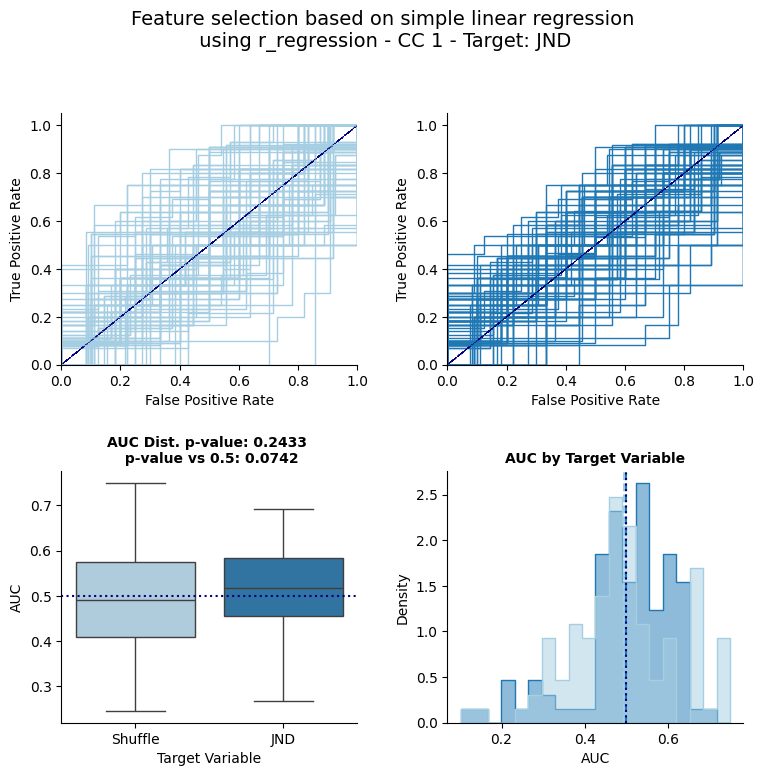

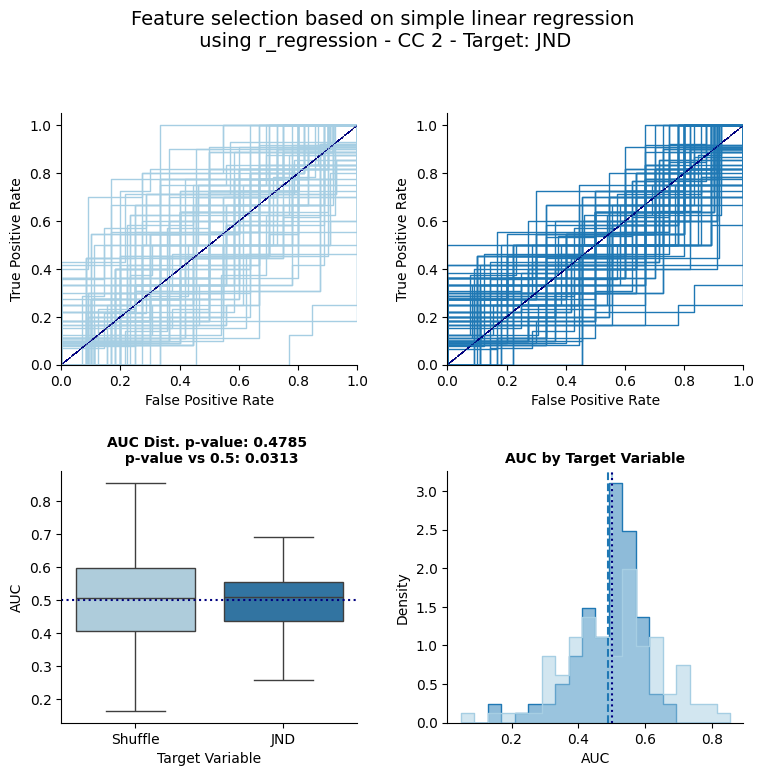

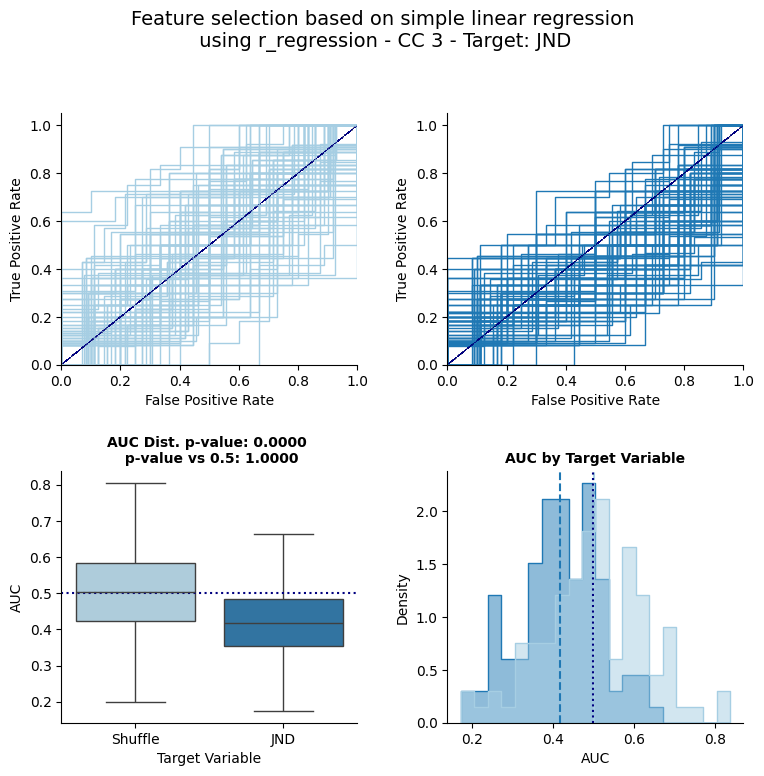

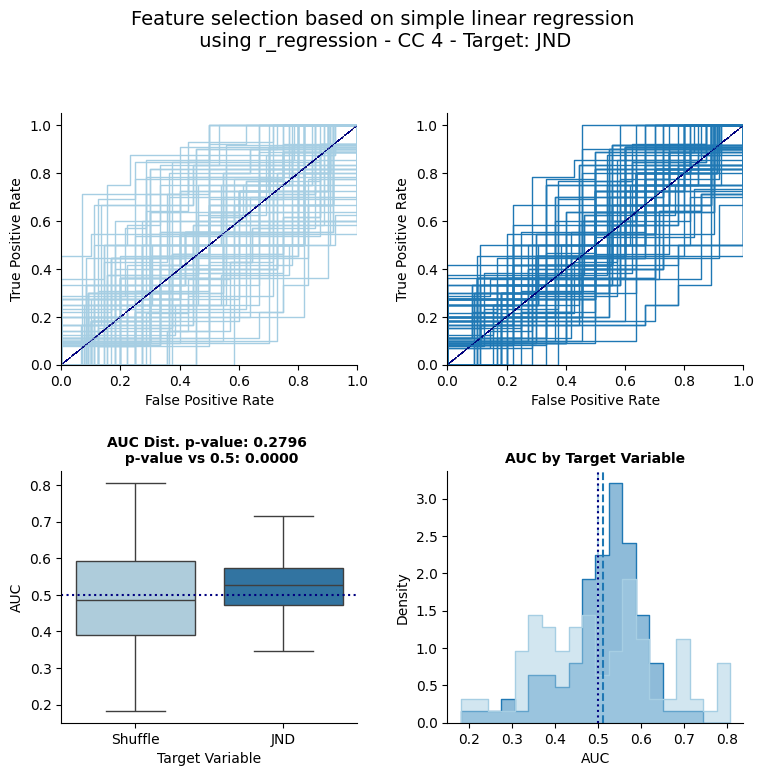

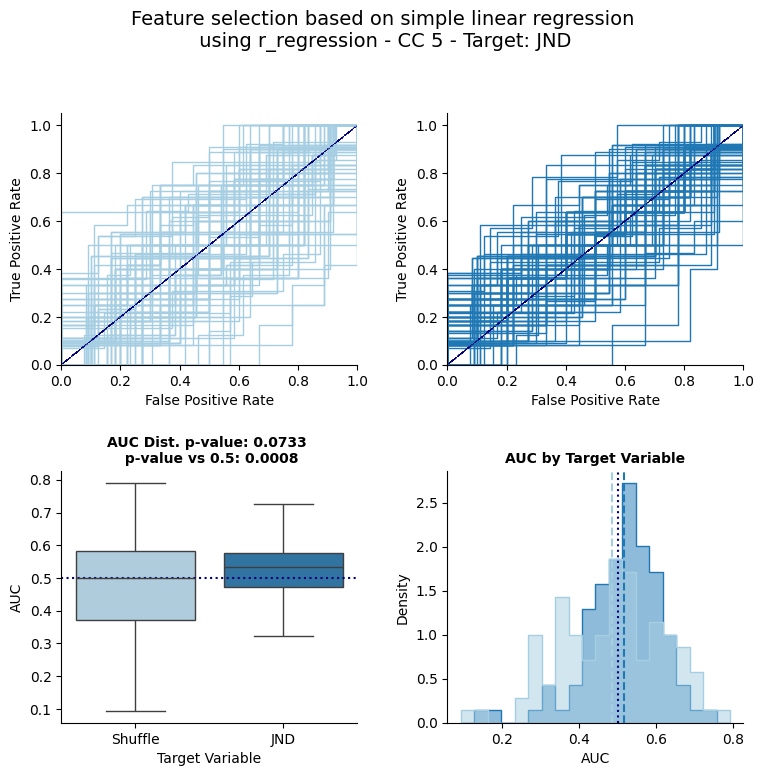

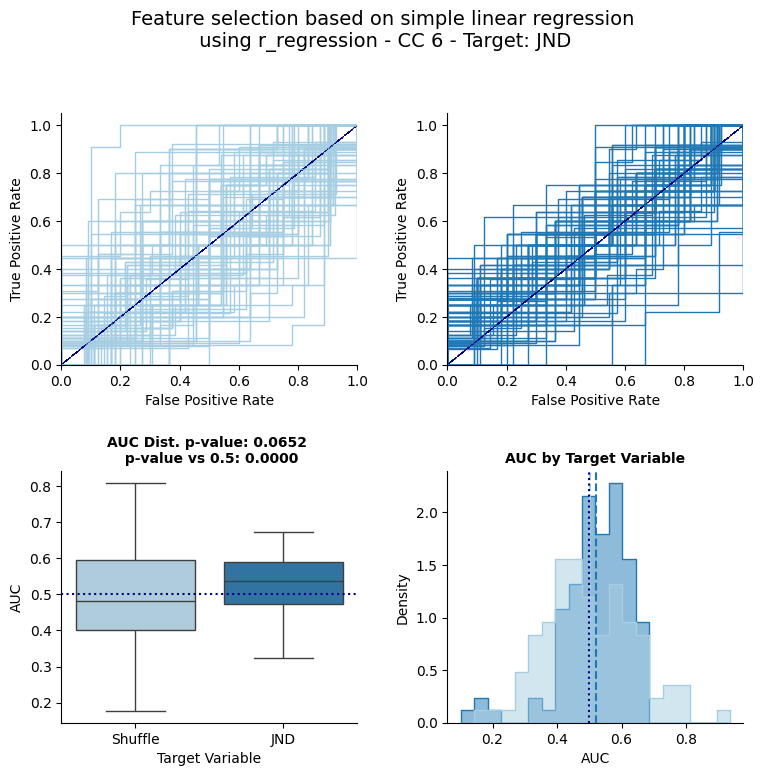

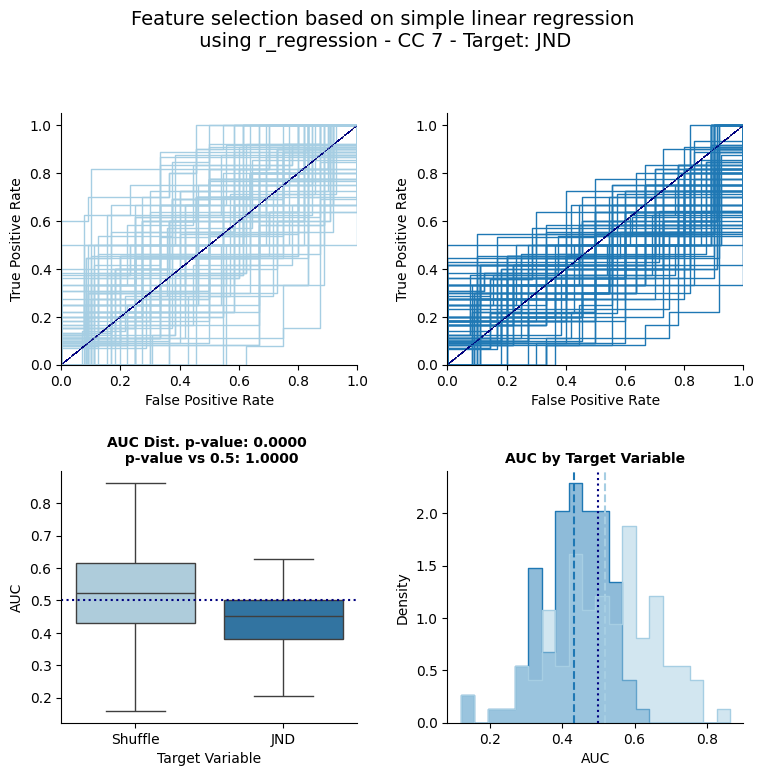

In [181]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score

palette_name='Paired'
colors = sns.color_palette(palette_name)
first_color = colors[0]
second_color = colors[1]

for cc in range(1,8):
    print(' ')

    print(f'CC {cc} - ROC Curve Analysis\n')

    bestfeat_tgt= 'JND'
    j=0
    

    X=DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+10]]


    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8,8))

    print(f'CC {cc} - Target: {bestfeat_tgt}\n')
    
    fig.suptitle(f'Feature selection based on simple linear regression\n using r_regression - CC {cc} - Target: {bestfeat_tgt}\n', fontsize=14)


    target_var=  ['Shuff', 'JND']

    roc_auc_all = [[] for _ in target_var]

    for i, target in enumerate(target_var):

        y=jnd_grouped


        for seed in range(100):
                                
            if target == 'Shuff':
                y = np.random.permutation(jnd_grouped)

            # Diviser les données en ensembles d'entraînement et de test
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=seed)

            # Entraîner un modèle de régression logistique
            model = LogisticRegression()
            model.fit(X_train, y_train)

            # Prédire les probabilités
            y_scores = model.predict_proba(X_test)[:, 1]

            # Calculer les taux de vrais positifs et de faux positifs
            fpr, tpr, thresholds = roc_curve(y_test, y_scores)

            # Calculer l'aire sous la courbe ROC (AUC)
            roc_auc = auc(fpr, tpr)

            # Tracer la courbe ROC
            axs[0,i].plot(fpr, tpr, color=colors[i], lw=1)
            axs[0,i].plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle=':')
            axs[0,i].set_xlim([0.0, 1.0])
            axs[0,i].set_ylim([0.0, 1.05])
            axs[0,i].set_xlabel('False Positive Rate')
            axs[0,i].set_ylabel('True Positive Rate')
            axs[0,i].spines['top'].set_visible(False)
            axs[0,i].spines['right'].set_visible(False)

            # Calculer l'AUC
            roc_auc = roc_auc_score(y_test, y_scores)
            roc_auc_all[i].append(roc_auc)
            # print(f'AUC: {roc_auc:.2f}')

    # t,pvalue=t_test_ind(roc_auc_all[0], roc_auc_all[1])
    # t1,pvalue1=t_test_ind(roc_auc_all[1], [0.5]*len(roc_auc_all[1]), alternative='greater')
    
    t, pvalue = stats.mannwhitneyu(roc_auc_all[0], roc_auc_all[1], alternative='two-sided')
    t1, pvalue1 = stats.mannwhitneyu(roc_auc_all[1], np.full_like(roc_auc_all[1], 0.5), alternative='greater')


    print(f'Mean AUC for Shuffle: {np.mean(roc_auc_all[0]):.4f} ± {np.std(roc_auc_all[0]):.4f}')
    print(f'Mean AUC for JND: {np.mean(roc_auc_all[1]):.4f} ± {np.std(roc_auc_all[1]):.4f}')
    print(f'P-value from independent t-test: {pvalue:.4f}')
    print(f'P-value from one-sample t-test against 0.5: {pvalue1:.4f}')


    df=pd.DataFrame({'AUC': roc_auc_all[0] + roc_auc_all[1], 'Target': ['Shuffle']*len(roc_auc_all[0]) + ['JND']*len(roc_auc_all[1])})

    sns.boxplot(x='Target', y='AUC', data=df, ax=axs[1,0], palette='Paired',showfliers=False)
    axs[1,0].set_title(f'AUC Dist. p-value: {pvalue:.4f} \n p-value vs 0.5: {pvalue1:.4f}', fontsize=10,fontweight='bold')
    axs[1,0].set_xlabel('Target Variable')
    axs[1,0].set_ylabel('AUC')
    axs[1,0].spines['top'].set_visible(False)
    axs[1,0].spines['right'].set_visible(False)   
    axs[1,0].axhline(y=0.5, color='navy', linestyle=':', label='AUC = 0.5')

    sns.histplot(data=df, x='AUC', hue='Target', element='step', stat='density', common_norm=True, ax=axs[1,1], palette='Paired', alpha=0.5,legend=False,bins=20,line_kws={'linewidth': 2})
    axs[1,1].set_xlabel('AUC')
    axs[1,1].set_title('AUC by Target Variable', fontsize=10,fontweight='bold')
    axs[1,1].spines['top'].set_visible(False)
    axs[1,1].spines['right'].set_visible(False)
    axs[1,1].axvline(x=np.mean(roc_auc_all[0]), color=first_color, linestyle='--', label='Mean AUC Shuffle')
    axs[1,1].axvline(x=np.mean(roc_auc_all[1]), color=second_color, linestyle='--', label='Mean AUC JND')
    axs[1,1].axvline(x=0.5, color='navy', linestyle=':', label='AUC = 0.5')
   
    plt.tight_layout(pad=2.0)

    plt.savefig(os.path.join(pathfig, f'ROC_Curve_CC{cc}_{bestfeat_tgt}.png'), dpi=300)

        

In [182]:
from scipy import stats
stat, p_value = stats.shapiro(roc_auc_all[1])
print(f'Shapiro-Wilk test statistic: {stat:.4f}, p-value: {p_value:.4f}')
if p_value > 0.05:
        print("Les données semblent normales (ne rejeter pas H0)")
else:
        print("Les données ne semblent pas normales (rejeter H0)")
    
stat, p_value = stats.mannwhitneyu(roc_auc_all[0], roc_auc_all[1], alternative='two-sided')
print(f'Mann-Whitney U test statistic: {stat:.4f}, p-value: {p_value:.4f}')

stat, p_value = stats.mannwhitneyu(roc_auc_all[1], np.full_like(roc_auc_all[1], 0.5), alternative='greater')
print(f'Wilcoxon signed-rank test statistic: {stat:.4f}, p-value: {p_value:.4f}')

Shapiro-Wilk test statistic: 0.9598, p-value: 0.0039
Les données ne semblent pas normales (rejeter H0)
Mann-Whitney U test statistic: 6875.5000, p-value: 0.0000
Wilcoxon signed-rank test statistic: 2700.0000, p-value: 1.0000


CC 1: P-value for the overall model: 0.0630
CC 2: P-value for the overall model: 0.1316
CC 3: P-value for the overall model: 0.1580
CC 4: P-value for the overall model: 0.0965
CC 5: P-value for the overall model: 0.0450
CC 6: P-value for the overall model: 0.1142
CC 7: P-value for the overall model: 0.6860


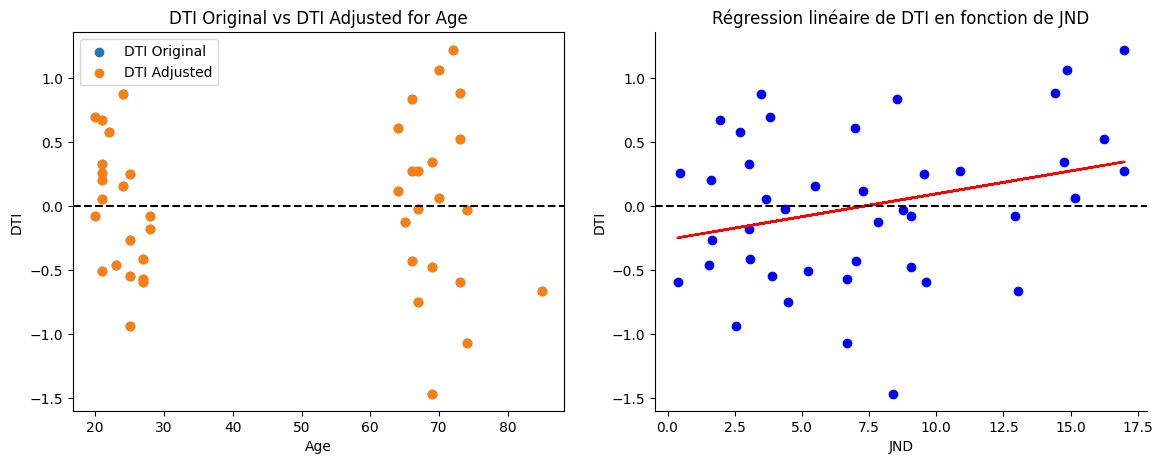

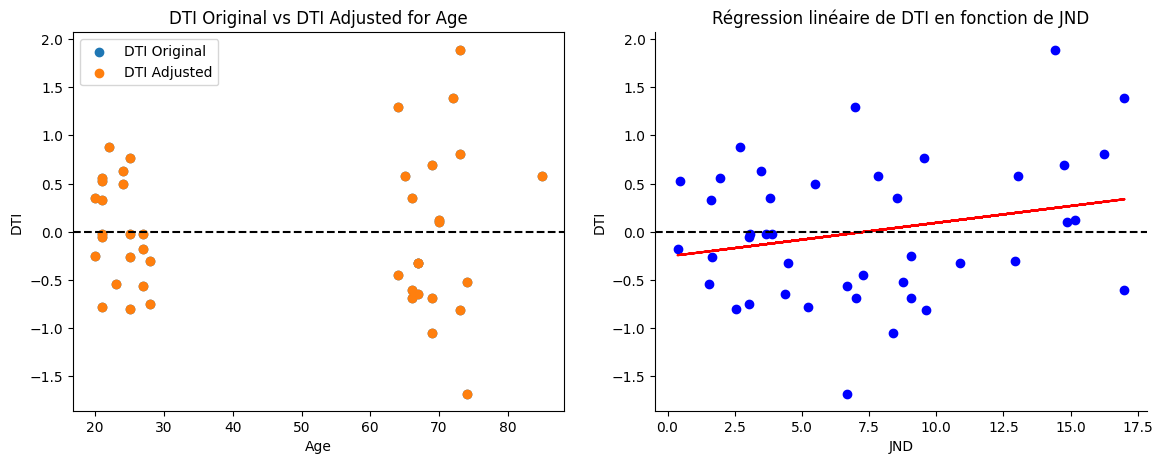

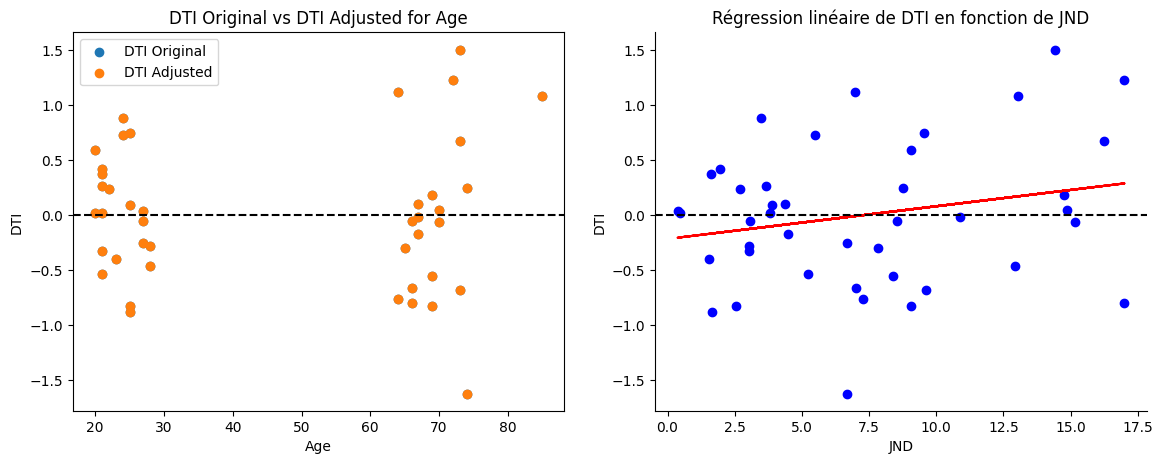

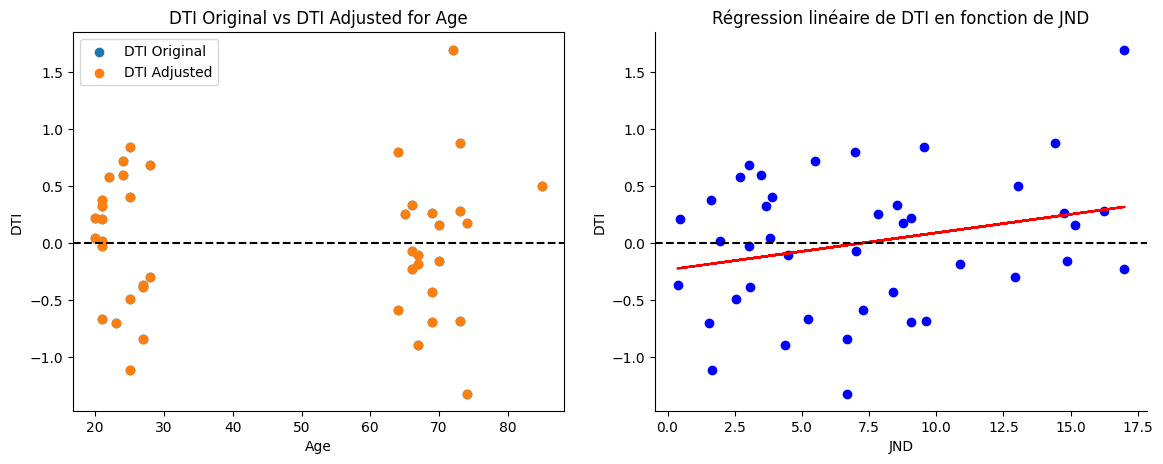

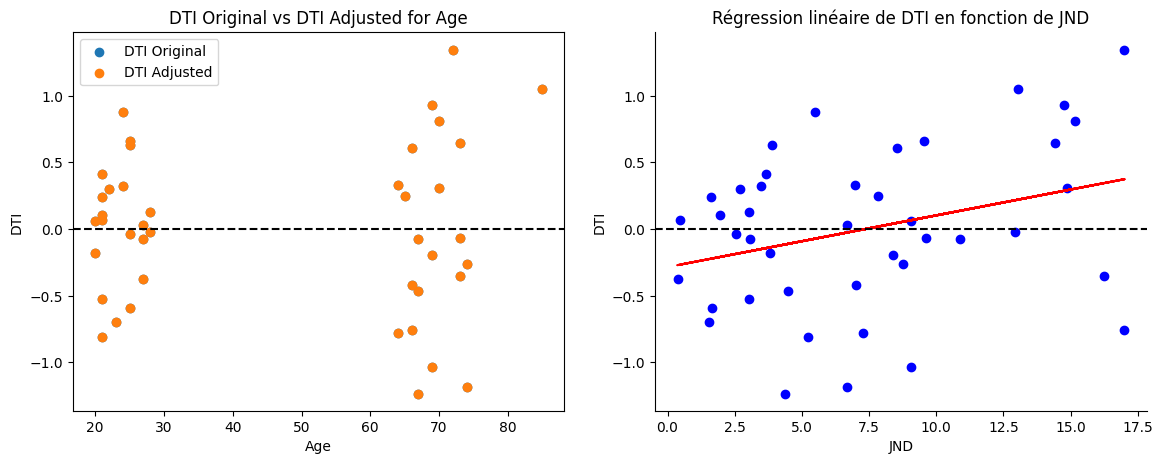

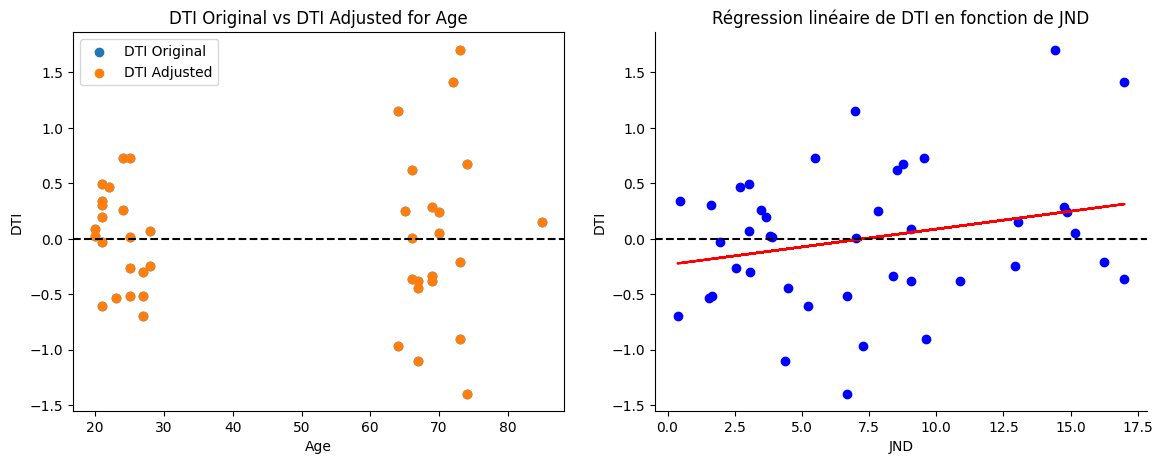

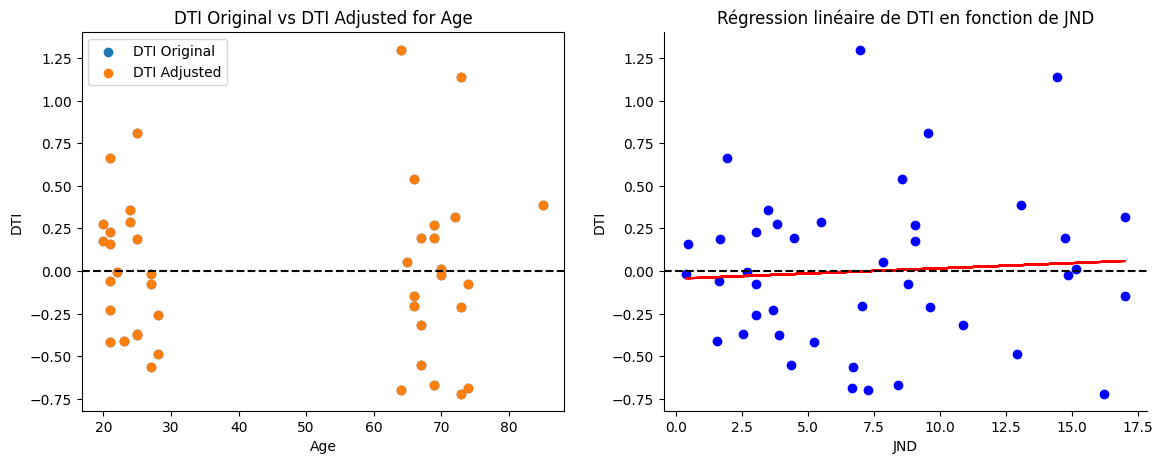

In [183]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

for cc in range(1,8):
        
    data = DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+10].tolist()].mean(axis=1)

    data_adjusted = data.copy()

    ### enlever l'effet de l'âge sur le DTI

    # Ajouter une constante à la variable indépendante
    X = sm.add_constant(age)
    y = data

    # Créer le modèle de régression multiple
    model = sm.OLS(y, X)

    # Ajuster le modèle
    results = model.fit()   

    # Calculer les résidus
    residuals = results.resid

    # Mettre à jour les données DTI avec les résidus
    data_adjusted = residuals

    ## test l effet du JND sur le DTI ajusté pour l'âge

    X = sm.add_constant(jnd)
    y = data_adjusted.values

    model = sm.OLS(y, X)
    results = model.fit()
    slope = results.params[1]
    intercept = results.params[0]
    regression_line = slope * jnd + intercept


    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    axs[0].scatter(age, data, label='DTI Original')
    axs[0].scatter(age, data_adjusted, label='DTI Adjusted')
    axs[0].set_xlabel('Age')
    axs[0].set_ylabel('DTI')
    axs[0].legend()
    axs[0].axhline(0, color='black', linestyle='--', label='Zero Line')
    axs[0].set_title('DTI Original vs DTI Adjusted for Age')

    axs[1].scatter(jnd, data_adjusted, color='blue', label='Données')
    axs[1].plot(jnd, regression_line, color='red', label='Régression linéaire')
    axs[1].set_xlabel('JND')
    axs[1].set_ylabel('DTI')
    axs[1].set_title('Régression linéaire de DTI en fonction de JND')
    axs[1].spines['top'].set_visible(False)
    axs[1].spines['right'].set_visible(False)
    axs[1].axhline(0, color='black', linestyle='--', label='Zero Line')
    plt.tight_layout(pad=2.0)

    # Afficher le graphique
    # print(results.summary())
    f_pvalue = results.f_pvalue
    print(f'CC {cc}: P-value for the overall model: {f_pvalue:.4f}')


In [184]:
r_pearson_DTI_JND=r_regression(DTI_JND, jnd)
best_DTI_JND_features = np.argsort(r_pearson_DTI_JND)[:10]
best_DTI_JND_features
r_pearson_DTI_JND

array([ 0.27892361,  0.2774166 ,  0.27499103,  0.27223656,  0.26719646,
        0.26657783,  0.26207775,  0.26039895,  0.25831374,  0.24958722,
        0.24092438,  0.23477547,  0.23456006,  0.22722083,  0.22637639,
        0.22588338,  0.22538806,  0.21719398,  0.2138389 ,  0.20935384,
        0.24651774,  0.22911187,  0.21672987,  0.19614901,  0.17846553,
        0.17038237,  0.16606226,  0.1591548 ,  0.15899691,  0.15778522,
        0.26398693,  0.24758903,  0.22947937,  0.22870611,  0.21807203,
        0.21764307,  0.2173638 ,  0.21291975,  0.2122141 ,  0.20925249,
        0.28716944,  0.27614705,  0.27401408,  0.26566555,  0.26521451,
        0.26024317,  0.25871238,  0.25852991,  0.25596036,  0.25327304,
        0.26450008,  0.23899159,  0.22862076,  0.22804454,  0.2255376 ,
        0.22332373,  0.22044604,  0.21753552,  0.21497985,  0.21073082,
        0.26138286,  0.25090483,  0.21995053,  0.20247095, -0.18681132,
        0.15767012, -0.14846041, -0.14761394, -0.1451915 ,  0.14

In [185]:
best_DTI_JND_features

array([64, 66, 67, 68, 69, 65, 29, 28, 27, 26])

In [186]:
DTI_JND.columns[best_DTI_JND_features].tolist()


['CC7_71',
 'CC7_83',
 'CC7_82',
 'CC7_72',
 'CC7_96',
 'CC7_33',
 'CC3_88',
 'CC3_66',
 'CC3_46',
 'CC3_5']

P-value for the overall model: 0.7882


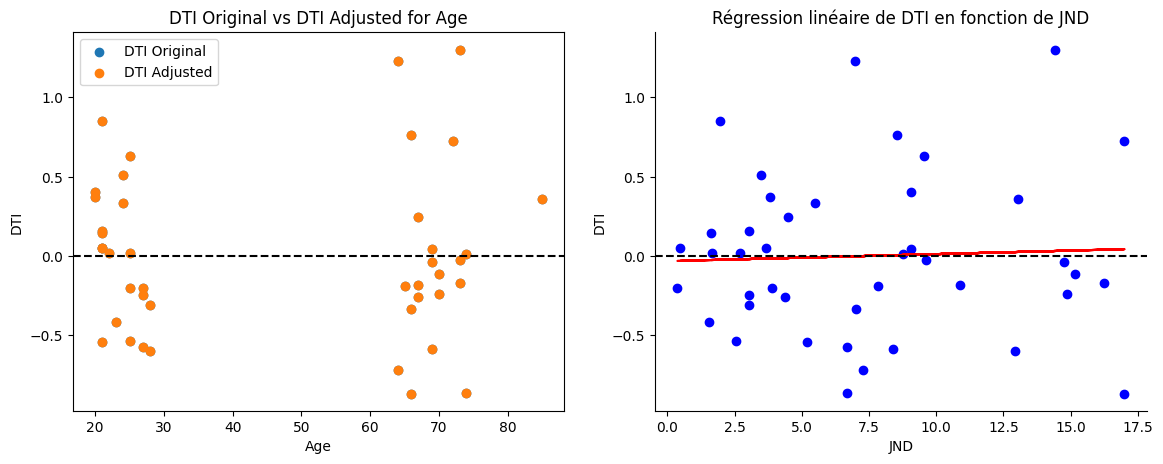

In [187]:
    
data = DTI_JND[DTI_JND.columns[best_DTI_JND_features].tolist()].mean(axis=1)

data_adjusted = data.copy()

### enlever l'effet de l'âge sur le DTI

# Ajouter une constante à la variable indépendante
X = sm.add_constant(age)
y = data

# Créer le modèle de régression multiple
model = sm.OLS(y, X)

# Ajuster le modèle
results = model.fit()   

# Calculer les résidus
residuals = results.resid

# Mettre à jour les données DTI avec les résidus
data_adjusted = residuals

## test l effet du JND sur le DTI ajusté pour l'âge

X = sm.add_constant(jnd)
y = data_adjusted.values

model = sm.OLS(y, X)
results = model.fit()
slope = results.params[1]
intercept = results.params[0]
regression_line = slope * jnd + intercept

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

axs[0].scatter(age, data, label='DTI Original')
axs[0].scatter(age, data_adjusted, label='DTI Adjusted')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('DTI')
axs[0].legend()
axs[0].axhline(0, color='black', linestyle='--', label='Zero Line')
axs[0].set_title('DTI Original vs DTI Adjusted for Age')

axs[1].scatter(jnd, data_adjusted, color='blue', label='Données')
axs[1].plot(jnd, regression_line, color='red', label='Régression linéaire')
axs[1].set_xlabel('JND')
axs[1].set_ylabel('DTI')
axs[1].set_title('Régression linéaire de DTI en fonction de JND')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].axhline(0, color='black', linestyle='--', label='Zero Line')
plt.tight_layout(pad=2.0)

# Afficher le graphique
# print(results.summary())
f_pvalue = results.f_pvalue
print(f'P-value for the overall model: {f_pvalue:.4f}')


ROC WITH ADJUSTED DATA 

                            OLS Regression Results                            
Dep. Variable:                    jnd   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     21.54
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           4.99e-07
Time:                        15:19:06   Log-Likelihood:                -110.28
No. Observations:                  42   AIC:                             226.6
Df Residuals:                      39   BIC:                             231.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5622      1.196      0.470      0.6

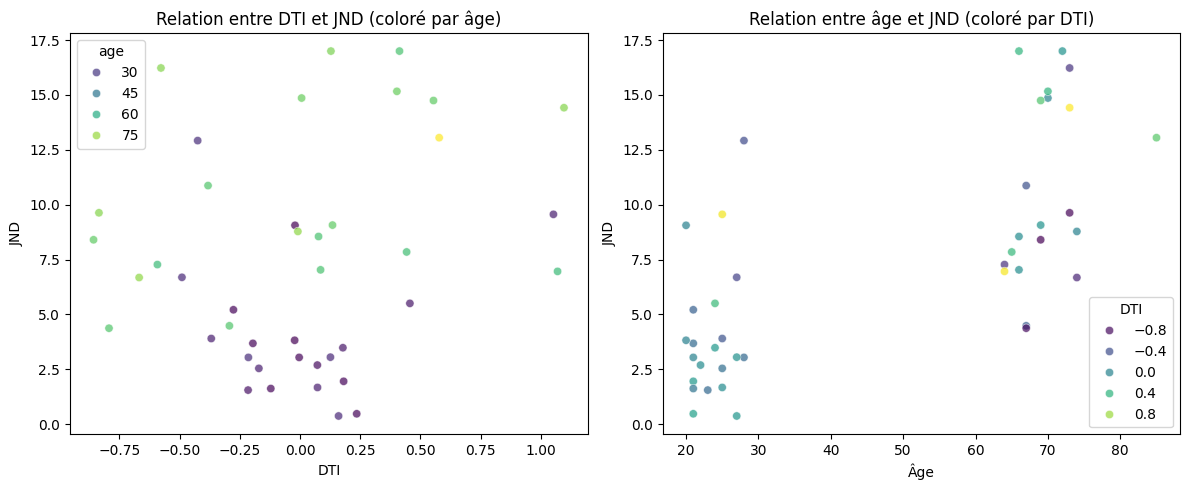

In [188]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

pvaDTIlue = []

for cc in range(1,8):
            
    data = DTI_JND[DTI_JND.columns[10*(cc-1):10*(cc-1)+5].tolist()].mean(axis=1)
    # 1. Charger tes données (remplace par ton fichier)
    # Exemple : df = pd.read_csv('ton_fichier.csv')
    # Je vais créer un exemple de données pour illustrer
    np.random.seed(42)
    n = 100
    df = pd.DataFrame({
        'DTI': data,  # Variable indépendante
        'age': age,  # Variable de contrôle
        'jnd': jnd   # Variable dépendante
    })

    # 2. Préparer les variables pour la régression
    X = df[['DTI', 'age']]  # Variables explicatives
    X = sm.add_constant(X)  # Ajoute une constante pour l'interception
    y = df['jnd']  # Variable à expliquer

    # 3. Ajuster le modèle de régression multiple
    model = sm.OLS(y, X).fit()


    pvaDTIlue.append(model.pvalues['DTI'])

print(model.summary())

# 4. Afficher les résultats de manière claire
print("\n--- Résultats de la régression ---")
print(f"Coefficient du DTI : {model.params['DTI']:.4f}")
print(f"P-valeur du DTI : {model.pvalues['DTI']:.4f}")
print(f"Coefficient de l'âge : {model.params['age']:.4f}")
print(f"P-valeur de l'âge : {model.pvalues['age']:.4f}")
print(f"R-carré : {model.rsquared:.3f}")
print(f"F-statistique : {model.fvalue:.2f} (p-valeur : {model.f_pvalue:.4f})")

# 5. Visualisation
plt.figure(figsize=(12, 5))

# Scatter plot : DTI vs JND, coloré par âge
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='DTI', y='jnd', hue='age', palette='viridis', alpha=0.7)
plt.title("Relation entre DTI et JND (coloré par âge)")
plt.xlabel("DTI")
plt.ylabel("JND")

# Scatter plot : Age vs JND
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='age', y='jnd', hue='DTI', palette='viridis', alpha=0.7)
plt.title("Relation entre âge et JND (coloré par DTI)")
plt.xlabel("Âge")
plt.ylabel("JND")

plt.tight_layout()
plt.show()

In [202]:
pvaDTIlue

[np.float64(0.00904982442737578),
 np.float64(0.030263819804786936),
 np.float64(0.05313375721561407),
 np.float64(0.030560413028482027),
 np.float64(0.0037869442278800802),
 np.float64(0.01994062963759227),
 np.float64(0.09386224341516743)]

In [201]:
[pvaDTIlue[i] * 7 for i in range(7)]


[np.float64(0.06334877099163046),
 np.float64(0.21184673863350856),
 np.float64(0.3719363005092985),
 np.float64(0.2139228911993742),
 np.float64(0.026508609595160562),
 np.float64(0.13958440746314588),
 np.float64(0.6570357039061719)]

In [190]:
f_reg_best_features_jnd_cc_allCC

array([[26, 27, 25, 28, 36, 24, 37, 29, 35, 23],
       [33, 32, 34, 35, 47, 46, 31, 30, 36, 29],
       [ 1,  0,  2,  3,  4, 45,  5, 46, 66, 88],
       [82, 83, 84, 81, 85, 50, 87, 86, 61, 51],
       [ 0,  1, 88, 17, 60, 62, 59, 61, 87, 90],
       [68, 69, 63, 95, 94, 62, 64, 61, 27, 66],
       [36, 35, 34, 37, 71, 33, 83, 82, 72, 96]])

In [191]:
r_reg_best_features_jnd_cc_allCC

array([[38, 23, 35, 29, 37, 24, 36, 28, 25, 27],
       [45, 29, 36, 30, 31, 46, 47, 35, 34, 32],
       [ 6, 88, 66, 46,  5, 45,  4,  3,  2,  0],
       [ 1, 51, 61, 86, 87, 50, 85, 81, 84, 83],
       [ 2, 90, 87, 61, 59, 62, 60, 17, 88,  1],
       [65, 66, 27, 61, 64, 62, 94, 95, 63, 69],
       [61, 39, 95, 97, 38, 96, 33, 37, 34, 35]])

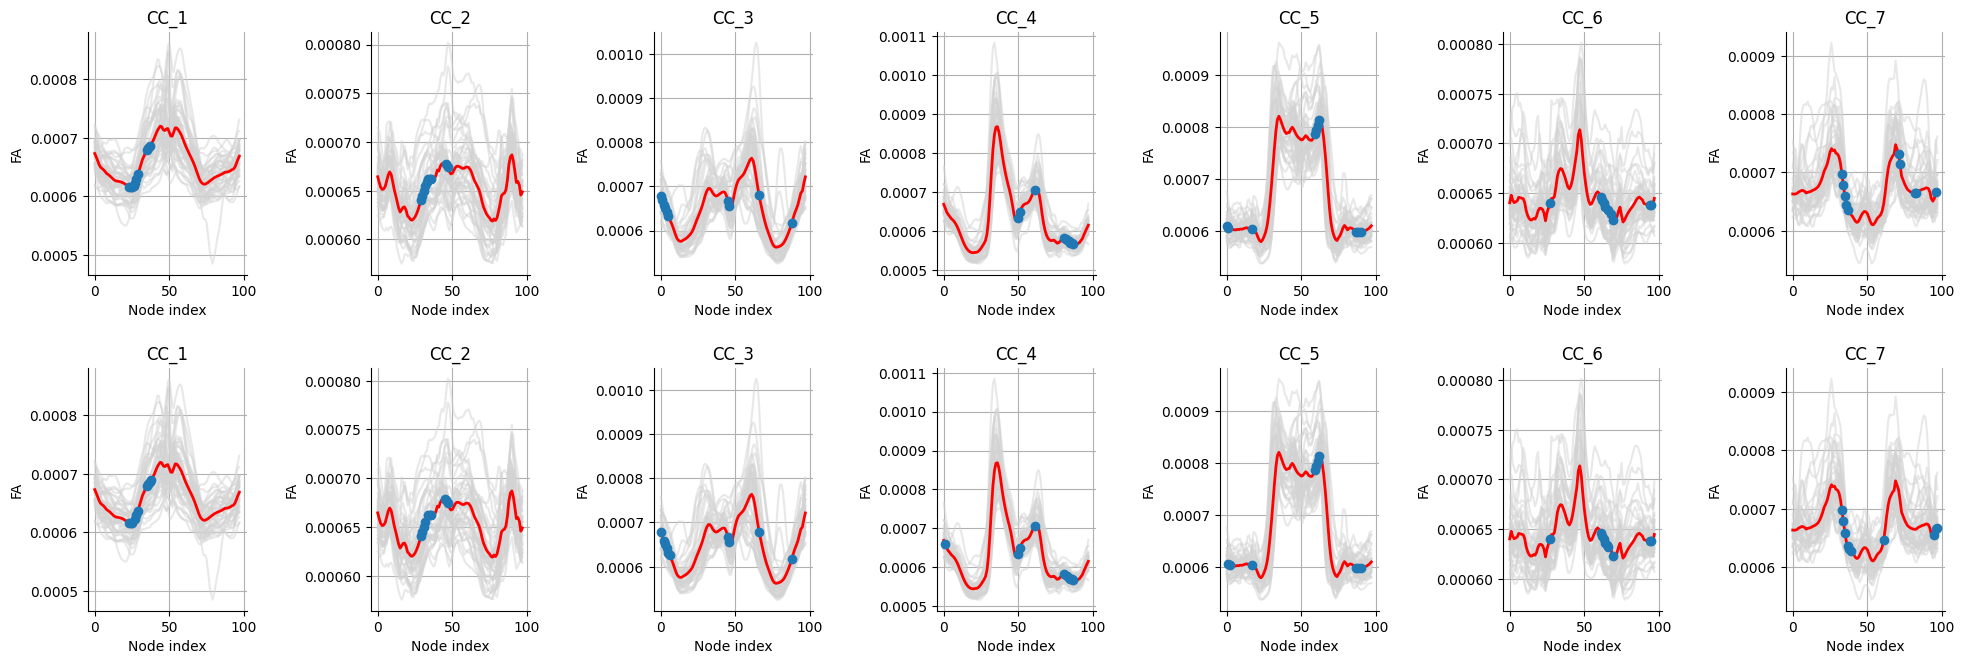

In [192]:

CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']
fig, axs = plt.subplots(nrows=2, ncols=7, figsize=(20, 7))

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[0,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[0,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[0,i].plot(f_reg_best_features_jnd_cc_allCC[i,:], DTI[:,f_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features Age')
    axs[0,i].set_xlabel('Node index')
    axs[0,i].set_ylabel('FA')
    axs[0,i].grid(True)
    axs[0,i].spines['top'].set_visible(False)
    axs[0,i].spines['right'].set_visible(False)
    axs[0,i].set_title(CCx)
   

for i, CCx in enumerate(CCx_list[0:7]):
    file_path = os.path.join(pathcsv, f'{CCx}_FA{addtotitle}.csv')

    axs[1,i].plot(DTI[:,:,i].T, color='lightgray', alpha=0.5)
    axs[1,i].plot(DTI[:,:,i].mean(axis=0), color='red', linewidth=2)
    axs[1,i].plot(r_reg_best_features_jnd_cc_allCC[i,:], DTI[:,r_reg_best_features_jnd_cc_allCC[i,:],i].mean(axis=0), 'o', linewidth=2, label='Best features JND')
    axs[1,i].set_xlabel('Node index')
    axs[1,i].set_ylabel('FA')
    axs[1,i].grid(True)
    axs[1,i].spines['top'].set_visible(False)
    axs[1,i].spines['right'].set_visible(False)
    axs[1,i].set_title(CCx)

plt.tight_layout(pad=2.0)
